# Join `confirmed retrievals` and `emr_cycle_aspirations_processed` and analyze combined data # confirmed egg retrievals

A first-pass cleaning and joining of the oocyte tables before analysis.

What this notebook does, in order:
1. **Inner Join** based on patid and cycle_id
#2. **Drop** columns that are completely empty
#3. **Review** columns that hold only a single value
#4. **Merge** the oocyte dataframes (by absolute_oocyteid)
#5. **Tidy** column types
#6. **Save** a cleaned copy + keep an audit note of what changed

The same `profile()` function works on the other `emr_*` tables too, so you can reuse this pattern.

> **Before running:** finish the venv setup in this repo and install the packages — open a terminal and run `pip install pandas pyarrow`. The `requirements.txt` alongside this notebook lists everything.
>
> **Important:** keep your raw patient data in a `data/` folder that is git-ignored. Don't commit EMR exports to GitHub, even a private repo.

## Setup

In [87]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import import_ipynb

import helper_functions

In [88]:
# --- loading retrievals df ---
retrievals_PATH = Path("../data/retrieval_cycles.csv")

# loading data
retrievals_df = pd.read_csv(retrievals_PATH)

# --- loading aspirations df ---
aspirations_PATH = Path("../data/emr_cycle_aspirations_processed.csv")

# loading data
aspirations_df = pd.read_csv(aspirations_PATH)

# --- loading patient map df ---
map_PATH = Path("../data/patient_map.csv")

#loading data
map_df = pd.read_csv(map_PATH)

In [89]:
#setting display options to show all columns and full width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Allow full width

## 1. Inner join

on cycleid and patid for retrievals and aspirations

on patient_id and patid for patient_map

In [90]:
merged_df = retrievals_df.merge(
    aspirations_df,
    on=["patid", "cycleid"],
    how="inner"
)

In [91]:
# Merge onto merged_df, matching patid ↔ patient_id
merged_df = merged_df.merge(
    map_df,
    left_on='patid',
    right_on='patient_id',
    how='left'
)

# Ensure both date columns are datetime
merged_df['cyclestart'] = pd.to_datetime(merged_df['cyclestart'], errors='coerce')
merged_df['dob']        = pd.to_datetime(merged_df['dob'],        errors='coerce')

## 2. Clean data

In [92]:
#getting rid of test patients
merged_df = helper_functions.remove_rows_by_values(merged_df, "patid")

In [61]:
corrections = {
    "aa9bac9c-96c5-492c-aae5-a54e952ef00f": {"cyclestart": "2022-01-02"}, # stim_start for cycleid aa9bac9c-96c5-492c-aae5-a54e952ef00f should be "2022-01-02"
    "4ed8b64a-515a-4140-908e-8626d1c31f42": {"cyclestart": "2022-04-19"}, # stim_start for cycleid 4ed8b64a-515a-4140-908e-8626d1c31f42 should be "2022-04-19"
    "1254091f-596f-4690-bc1e-5bcea625a250": {"retrieved": "2025-01-29", "cyclestart": "2025-01-17",}, # retrieval_date for cycleid 1254091f-596f-4690-bc1e-5bcea625a250 should be "2025-01-29" and stim_start should be "2025-01-17"
    "be9f2dac-54b0-427d-b931-bd03a744af66": {"cyclestart": "2025-01-16"}, # stim_start for cycleid be9f2dac-54b0-427d-b931-bd03a744af66 should be "2025-01-16"
    "da81cbe4-e218-40cf-9c31-f97da2c53369": {"cyclestart": "2025-10-24"}, # stim_start for cycleid da81cbe4-e218-40cf-9c31-f97da2c53369 should be "2025-10-24"
    "fee4eac5-8ed2-45b3-b27e-8173fcece29a": {"retrieved": "2022-05-07"}, # retrieval date for cycleid fee4eac5-8ed2-45b3-b27e-8173fcece29a should be "2022-05-07",
    "e2156d14-5852-44b2-b58e-3ad80ff57808": {"retrieved": "2026-03-25"}, # retrieval date for cycleid e2156d14-5852-44b2-b58e-3ad80ff57808 should be "2026-03-25"
    "696c0552-c304-4f62-955a-c28f10a17c2b": {"retrieved": "2025-04-30"}, # retrieval date for cycle 696c0552-c304-4f62-955a-c28f10a17c2b should be "2025-04-30"
    "83308252-dc41-47a4-91cb-e97c5a6a6890": {"cyclestart": "2026-06-17"}, # cycle start for cycle 83308252-dc41-47a4-91cb-e97c5a6a6890 should be "2026-06-17"
    "26c5026e-f829-4509-9de9-e3a75a41e6f1": {"cyclestart": "2024-11-15"}, # cycle start for cycle 26c5026e-f829-4509-9de9-e3a75a41e6f1 should be "2024-11-15"
    "c8a8646b-8462-4896-8eec-7b2c9333f791": {"cyclestart": "2025-07-24"}, # cycle start for cycle c8a8646b-8462-4896-8eec-7b2c9333f791 should be "2025-07-24"
    "8373a9a0-ba7f-452a-8917-f6993d56edb3": {"cyclestart": "2023-11-16"}, # cycle start for cycle 8373a9a0-ba7f-452a-8917-f6993d56edb3 should be "2023-11-16"
    "920b65de-0842-4848-8768-79fe5d66068c": {"cyclestart": "2024-07-20"}, # cycle start for cycle 920b65de-0842-4848-8768-79fe5d66068c should be "2024-07-20"
    "43a8df91-fbdc-4044-8b61-98400d3bcd8c": {"height": 160, "weight": 60.3, "bmi": 23.6},
    "ac675966-d4b9-4c4c-86da-89849a6ac7d0": {"bmi": 33.0},
    "81460a38-76b1-4023-b190-8663c6f118a2": {"bmi": 33.0},
}

for cycleid, updates in corrections.items():
    mask = merged_df["cycleid"] == cycleid
    for col, value in updates.items():
        merged_df.loc[mask, col] = value

In [62]:
merged_df["cyclestart"] = pd.to_datetime(merged_df["cyclestart"], errors='coerce')
merged_df["retrieved"]   = pd.to_datetime(merged_df["retrieved"],   errors='coerce')
merged_df["stim_duration"] = (merged_df["retrieved"] - merged_df["cyclestart"]).dt.days

In [63]:
# Rows with stim_duration outside typical 8-20 day range
outliers = merged_df[
    (merged_df['stim_duration'] < 8) | (merged_df['stim_duration'] > 20)
]

print(f"Total outliers: {len(outliers)}")
print(f"  < 8 days:  {(outliers['stim_duration'] < 8).sum()}")
print(f"  > 20 days: {(outliers['stim_duration'] > 20).sum()}")
print(f"\nDistribution of outlier values:")
print(outliers['stim_duration'].describe())

# View them
outliers[['patid', 'cycleid', 'cyclestart', 'retrieved',
          'stim_duration', 'cycle_name', 'protocol_family_broad',
          'protocol_family', 'protocol_family_regex']].sort_values('stim_duration')

Total outliers: 5
  < 8 days:  0
  > 20 days: 5

Distribution of outlier values:
count     5.00000
mean     25.60000
std       4.97996
min      21.00000
25%      23.00000
50%      25.00000
75%      25.00000
max      34.00000
Name: stim_duration, dtype: float64


,patid,cycleid,cyclestart,retrieved,stim_duration,cycle_name,protocol_family_broad,protocol_family,protocol_family_regex
2797,127455,26a63aa2-17ad-4427-9ad9-ef1c77bddd0b,2026-01-17,2026-02-07 07:46:00,21.0,Kaiser IVF: Freeze All - Autologous: BCPA Gona...,IVF,BCPA,BCPA Gonadotropins + Clomid + +/- Adjuvants
1102,107426,3eac6984-0cf0-47fb-8ab2-6b51fccc8017,2025-10-23,2025-11-15 08:58:00,23.0,IVF: Freeze All - Autologous: MLEA Gonadotropi...,IVF,MLEA,MLEA Gonadotropins + Clomid + +/- Adjuvants
2384,39246,70aa4da8-371b-4393-bbb3-a81d8f053ddd,2024-02-13,2024-03-09 07:34:00,25.0,IVF: Freeze All - Autologous: Long Estrace Gon...,IVF,Long Estrace,Long Estrace Gonadotropins + Clomid + +/- Adju...
3068,122635,1263bef7-a959-4880-9601-3f0dbcbab57d,2026-06-11,2026-07-06 12:38:00,25.0,IVF: Freeze All - Autologous: BCPA Gonadotropi...,IVF,BCPA,BCPA Gonadotropins + Clomid + +/- Adjuvants
2014,54589,0558210d-ea1f-4c1e-8ce6-534c0f28e224,2024-02-16,2024-03-21 12:48:00,34.0,IVF: Freeze All - Autologous: Random Stim Start,IVF,Random Stim Start,Random Stim Start


In [64]:
# calculating age_at_stim

# Age at stim (in years) — divide by 365.25 to account for leap years
merged_df['age_at_stim'] = (
    (merged_df['cyclestart'] - merged_df['dob']).dt.days / 365.25
)

# Sanity checks
print(f"age_at_stim missing: {merged_df['age_at_stim'].isna().sum()}")
print(f"\nDistribution:")
print(merged_df['age_at_stim'].describe())

age_at_stim missing: 4

Distribution:
count    3082.000000
mean       36.828424
std         4.295971
min        12.553046
25%        34.321013
50%        36.974675
75%        39.741958
max        47.559206
Name: age_at_stim, dtype: float64


In [65]:
print(merged_df.columns)

Index(['cycleid', 'patid', 'partnerid', 'sart_id', 'status', 'closed',
       'cycletype', 'cycle_name', 'cycle_type', 'clinic', 'protocol_family',
       'protocol_detail', 'protocol_family_broad', 'protocol_family_uuid',
       'protocol_family_regex', 'adjuvants', 'cyclestart', 'cycleend',
       'end_reason', 'event_labels', 'plan_treatment', 'hist_monthsattempting',
       'main_note', 'height', 'weight', 'bmi', 'hist_smoker',
       'hist_pat_surg_sterile', 'doctor', 'art_reason', 'id', 'retrieved',
       'retrievedby', 'oocytes_retrieved', 'complication', 'note',
       'denuding_performed', 'denuding_performedby', 'retrievedtech',
       'labassistant', 'scrub_tech', 'crna', 'needle_type', 'duration',
       'accession_number', 'needle_type_cleaned', 'patient_id', 'account',
       'dob', 'stim_duration', 'age_at_stim'],
      dtype='str')


In [66]:
# Deduplicate to cycle level (stim_duration is per-cycle)
df_cycle = merged_df.drop_duplicates('cycleid').copy()

In [67]:
# calculating BMI for the cases where bmi does not make a lot of sense
# Identify the mixed-unit rows: currently flagged by absurd BMI > 60
mixed_units = merged_df['bmi'] > 60

# Show before
print("Before fix:")
print(merged_df.loc[mixed_units, ['patid', 'cycleid', 'height', 'weight', 'bmi']])

# Convert weight from lb to kg for those rows
merged_df.loc[mixed_units, 'weight'] = merged_df.loc[mixed_units, 'weight'] * 0.4536

# Recompute BMI (height in cm, weight now in kg)
merged_df.loc[mixed_units, 'bmi'] = (
    merged_df.loc[mixed_units, 'weight'] / (merged_df.loc[mixed_units, 'height'] / 100)**2
)

# Show after
print("\nAfter fix:")
print(merged_df.loc[mixed_units, ['patid', 'cycleid', 'height', 'weight', 'bmi']])

Before fix:
Empty DataFrame
Columns: [patid, cycleid, height, weight, bmi]
Index: []

After fix:
Empty DataFrame
Columns: [patid, cycleid, height, weight, bmi]
Index: []


In [68]:
# separating the broad protocol from the protocol family regex
def extract_base(pfr):
    """
    Get just the base protocol name from protocol_family_regex,
    stripping off all modifiers (Gonadotropins, Clomid, Adjuvants, etc.).
    """
    if pd.isna(pfr):
        return None
    s = str(pfr)
    # Check in priority order (most specific first)
    if 'BCPA' in s:                           return 'BCPA'
    if 'BCP Lupron Overlap' in s:             return 'BCP Lupron Overlap'
    if 'BCP' in s:                            return 'BCP'
    if 'MLEA Low Stim' in s:                  return 'MLEA Low Stim'
    if 'MLEA' in s:                           return 'MLEA'
    if 'Long Estrace' in s:                   return 'Long Estrace'
    if 'ONCO Random' in s:                    return 'ONCO Random Stim Start'
    if 'Random Stim Start' in s:              return 'Random Stim Start'
    if 'MidLuteal' in s:                      return 'MidLuteal Stim Start'
    if 'Follicular Phase' in s:               return 'Follicular Phase Stim Start'
    if 'CD3' in s:                            return 'CD3 Stim Start'
    return s   # anything unmatched keeps its original label

df_cycle['protocol_base_from_regex'] = df_cycle['protocol_family_regex'].apply(extract_base)

print(df_cycle['protocol_base_from_regex'].value_counts(dropna=False))

# Exclude the 46 unspecified-protocol rows
df_pca = df_cycle[df_cycle['protocol_base_from_regex'].notna()].copy()
print(f"Cycles for PCA: {len(df_pca)}")
print(df_pca['protocol_base_from_regex'].value_counts())

protocol_base_from_regex
MLEA                           1819
BCPA                            591
Random Stim Start               371
Long Estrace                    225
NaN                              46
BCP Lupron Overlap               17
BCP                               6
MidLuteal Stim Start              1
Follicular Phase Stim Start       1
CD3 Stim Start                    1
MLEA Low Stim                     1
ONCO Random Stim Start            1
Name: count, dtype: int64
Cycles for PCA: 3034
protocol_base_from_regex
MLEA                           1819
BCPA                            591
Random Stim Start               371
Long Estrace                    225
BCP Lupron Overlap               17
BCP                               6
MidLuteal Stim Start              1
Follicular Phase Stim Start       1
CD3 Stim Start                    1
MLEA Low Stim                     1
ONCO Random Stim Start            1
Name: count, dtype: int64


In [69]:
# Bucket rare categories together
rare = df_cycle['protocol_base_from_regex'].value_counts()
rare_categories = rare[rare < 10].index.tolist()
df_cycle['protocol_base_from_regex'] = df_cycle['protocol_base_from_regex'].replace(
    {r: 'Other' for r in rare_categories}
)
print(df_cycle['protocol_base_from_regex'].value_counts())

protocol_base_from_regex
MLEA                  1819
BCPA                   591
Random Stim Start      371
Long Estrace           225
BCP Lupron Overlap      17
Other                   11
Name: count, dtype: int64


In [70]:
parsed = merged_df.apply(helper_functions.parse_cycle_row, axis=1, result_type='expand')
merged_df = pd.concat([merged_df, parsed], axis=1)

# Then rebuild df_cycle from the updated merged_df
stim_cycles = ['IVF', 'IVF + FET', 'IVF + Fresh ET', 'Oocyte Freeze']
df = merged_df[merged_df['protocol_family_broad'].isin(stim_cycles)]
df = df[df['stim_duration'].between(5, 20)]
df_cycle = df.drop_duplicates('cycleid').copy()

In [71]:
med_cols = ['has_lupron_overlap', 'has_gonadotropins', 'has_clomid',
            'has_menopur', 'has_low_stim', 'has_letrozole', 'adjuvants_flag']
present = [c for c in med_cols if c in df_cycle.columns]
missing = [c for c in med_cols if c not in df_cycle.columns]
print(f"Present in df_cycle: {present}")
print(f"Missing from df_cycle: {missing}")

Present in df_cycle: ['has_lupron_overlap', 'has_gonadotropins', 'has_clomid', 'has_menopur', 'has_low_stim', 'has_letrozole', 'adjuvants_flag']
Missing from df_cycle: []


In [75]:
df_cycle.sample(6)

,cycleid,patid,partnerid,sart_id,status,closed,cycletype,cycle_name,cycle_type,clinic,protocol_family,protocol_detail,protocol_family_broad,protocol_family_uuid,protocol_family_regex,adjuvants,cyclestart,cycleend,end_reason,event_labels,plan_treatment,hist_monthsattempting,main_note,height,weight,bmi,hist_smoker,hist_pat_surg_sterile,doctor,art_reason,id,retrieved,retrievedby,oocytes_retrieved,complication,note,denuding_performed,denuding_performedby,retrievedtech,labassistant,scrub_tech,crna,needle_type,duration,accession_number,needle_type_cleaned,patient_id,account,dob,stim_duration,age_at_stim,cycle_type,clinic,donor_type,protocol_family,protocol_detail,protocol_family_uuid,uuid_regex_agreement,classification_status,conversion,conversion_targets,original_cycle,adjuvants,freeze_all,unstimulated,stim_start_variant,protocol_family_regex,is_ivf,is_fet,is_iui,is_tic,is_tdi,is_oocyte_freeze,is_oocyte_thaw,is_embryo_thaw,is_embryo_freeze,is_mock,is_spontaneous,is_third_party,is_intended_parent,is_recipient,is_gc,is_egg_donor,is_donor_embryo,is_reciprocal,is_compassionate,is_autologous,is_kaiser,protocol_base,has_lupron_overlap,has_gonadotropins,has_clomid,has_letrozole,has_menopur,has_low_stim,adjuvants_flag,fet_medication
1370,87eb0497-f35a-4a6c-ba4e-f2a146ed7593,119830,NaN,n_17599,Active,False,ac36dd51-7809-4975-83de-48cda51987f5,Oocyte Freeze Cycle - Autologous: BCPA Gonadot...,Oocyte Freeze,RPSD,BCPA,BCPA Gonadotropins +/- Clomid +/- +/- Adjuvants,Oocyte Freeze,BCPA,BCPA Gonadotropins + Clomid + +/- Adjuvants,"['Gonadotropins', 'Clomid', '+/- Adjuvants']",2026-04-10,NaN,NaN,NaN,02672e1f-371b-433a-be83-8664dfe7412d,0.0,Lab Plan: Oocyte Vitrification for social fert...,170.18,58.059892,20.05,-98.0,-98.0,3,ARTReason_7=on,0227f5d4-d101-4dae-9e9c-6d1fea216a94,2026-04-20 10:00:00,3.0,13.0,NaN,NaN,2026-04-20 12:10:00-07,31.0,38.0,2487.0,285.0,Leann Johnson,double lumen needle,26,26-304,double lumen,119830,96475,1993-06-15,10.0,32.818617,Oocyte Freeze,RPSD,Autologous,BCPA,BCPA Gonadotropins +/- Clomid +/- +/- Adjuvants,BCPA,True,OK,False,None,None,"[Gonadotropins, Clomid, +/- Adjuvants]",False,False,NaN,BCPA Gonadotropins + Clomid + +/- Adjuvants,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,BCPA,False,True,True,False,False,False,+/-,None
145,b738f257-566a-469b-9f18-77e1c1b6b3ab,95938,99535.0,n_14939,Completed,True,5cf37237-dd8c-4bcc-ae5e-3da7717a21cb,IVF: Freeze All - Autologous: MLEA Gonadotropi...,IVF Freeze-All,RPSD,MLEA,MLEA Gonadotropins +/- Clomid +/- +/- Adjuvants,IVF,MLEA,MLEA Gonadotropins + Clomid + +/- Adjuvants,"['Gonadotropins', 'Clomid', '+/- Adjuvants']",2025-08-01,8/29/2025,NaN,NaN,4e625189-d13b-4ca1-9f4d-463506ae7a5f,2.0,"Lab Plan: ICSI with ZyMot, AH, PGT-A with Igen...",157.48,74.108010,29.88,-98.0,-98.0,6,NaN,be6a8089-98a6-480d-b861-ee2e75f5a705,2025-08-14 09:21:00,90.0,10.0,NaN,NaN,2025-08-14 12:24:00-07,37.0,32.0,3279.0,1366.0,Leann Johnson,double lumen needle,22,25-709,double lumen,95938,72583,1991-07-04,13.0,34.078029,IVF Freeze-All,RPSD,Autologous,MLEA,MLEA Gonadotropins +/- Clomid +/- +/- Adjuvants,MLEA,True,OK,False,None,None,"[Gonadotropins, Clomid, +/- Adjuvants]",True,False,NaN,MLEA Gonadotropins + Clomid + +/- Adjuvants,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,MLEA,False,True,True,False,False,False,+/-,None
2938,1198fe9c-d432-4c28-86d5-049f223b4b6a,73142,77359.0,n_13573,Completed,True,5cf37237-dd8c-4bcc-ae5e-3da7717a21cb,IVF: Freeze All - Autologous: MLEA Gonadotropi...,IVF Freeze-All,RPSD,MLEA,MLEA Gonadotropins +/- Clomid +/- +/- Adjuvants,IVF,MLEA,MLEA Gonadotropins + Clomid + +/- Adjuvants,"['Gonadotropins', 'Clomid', '+/- Adjuvants']",2025-03-06,10/29/2025,NaN,NaN,4e625189-d13b-4ca1-9f4d-463506ae7a5f,10.0,"Lab Plan: ICSI with ZyMot, CC, AH, PGT-A with ...",162.56,55.701209,21.08,-98.0,-98.0,1,NaN,d62bc0b5-cea9-446d-af6f-f2ed90a90ea8,2025-0

## 3. PCA (not clean)

Cycles in PCA: 2569
Features: 12

Feature list:
['age_at_stim', 'bmi', 'base_BCPA', 'base_Long Estrace', 'base_MLEA', 'has_lupron_overlap', 'has_gonadotropins', 'has_clomid', 'has_menopur', 'has_low_stim', 'adj_No', 'adj_None']

Explained variance per PC:
  PC1: 24.9%
  PC2: 17.8%
  PC3: 11.8%
  PC4: 10.3%
Cumulative (PC1-4): 64.8%


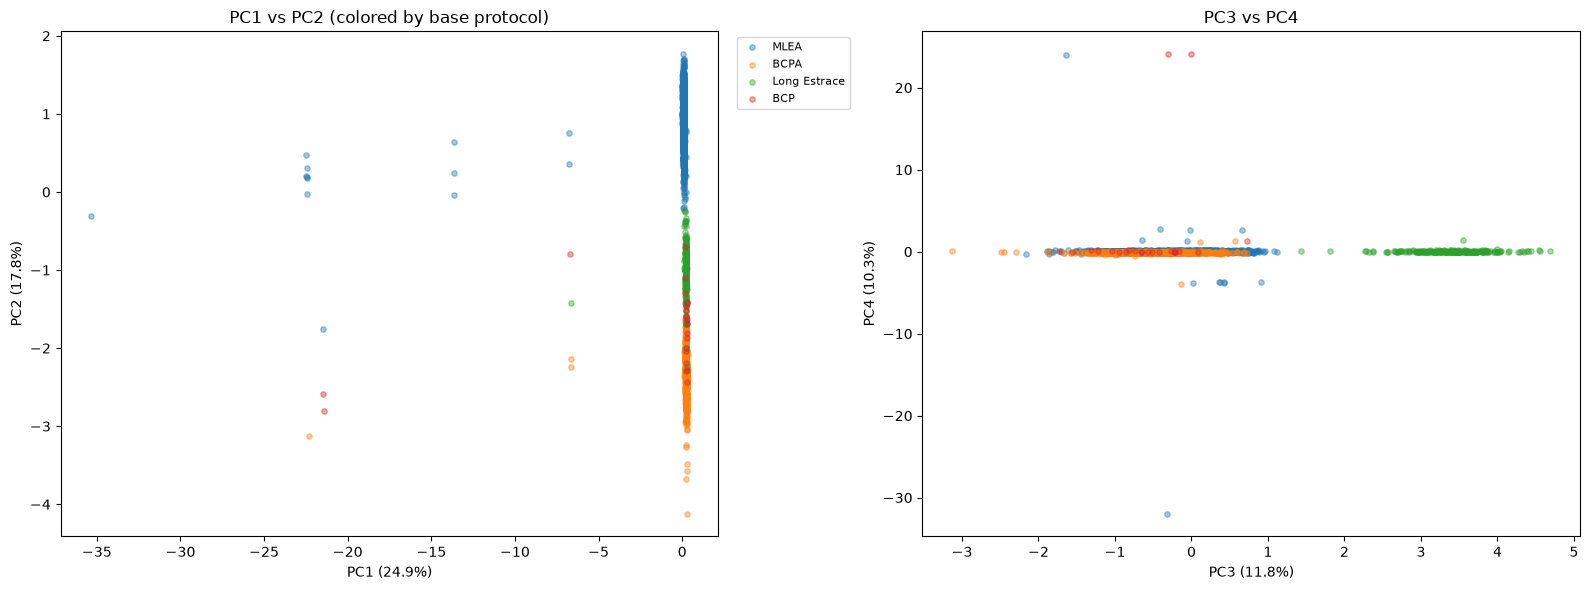


PC1 — top features by |loading|:
                     PC1
has_clomid         0.557
has_gonadotropins  0.557
adj_None          -0.490
adj_No            -0.268
has_low_stim      -0.255
base_BCPA          0.033
base_MLEA         -0.028
bmi               -0.026

PC2 — top features by |loading|:
                      PC2
base_MLEA           0.675
base_BCPA          -0.635
age_at_stim         0.330
base_Long Estrace  -0.149
has_lupron_overlap -0.076
adj_No             -0.042
has_gonadotropins   0.032
has_clomid          0.023

PC3 — top features by |loading|:
                      PC3
base_Long Estrace   0.786
age_at_stim         0.492
base_MLEA          -0.272
base_BCPA          -0.208
bmi                 0.139
has_lupron_overlap -0.047
has_gonadotropins  -0.019
adj_No             -0.017

PC4 — top features by |loading|:
                     PC4
adj_No             0.727
has_low_stim      -0.557
adj_None          -0.361
has_gonadotropins -0.109
has_clomid        -0.109
bmi                0.

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Exclude the 46 no-protocol rows
df_pca = df_cycle[df_cycle['protocol_base'].notna()].copy()

# --- Continuous features ---
continuous = ['age_at_stim', 'bmi']
continuous = [c for c in continuous if c in df_pca.columns]

# --- Base protocol as one-hot ---
base_dummies = pd.get_dummies(
    df_pca[['protocol_base']],
    prefix='base', drop_first=True
).astype(int)

# --- Modifier flags (already binary from parser) ---
# Convert bool → int, handle adjuvants_flag as a special 3-way category
modifier_bools = ['has_lupron_overlap', 'has_gonadotropins', 'has_clomid',
                  'has_menopur', 'has_low_stim']
modifier_bools = [c for c in modifier_bools if c in df_pca.columns]
mods = df_pca[modifier_bools].astype(int)

# adjuvants_flag is "+/-", "No", or None → one-hot it
if 'adjuvants_flag' in df_pca.columns:
    adj_dummies = pd.get_dummies(
        df_pca[['adjuvants_flag']].fillna('None'),
        prefix='adj', drop_first=True
    ).astype(int)
else:
    adj_dummies = pd.DataFrame(index=df_pca.index)

# --- Combine everything ---
X = pd.concat([df_pca[continuous], base_dummies, mods, adj_dummies],
              axis=1).dropna()
print(f"Cycles in PCA: {len(X)}")
print(f"Features: {X.shape[1]}")
print(f"\nFeature list:")
print(X.columns.tolist())

# --- Standardize and PCA ---
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=4).fit(X_scaled)  # ask for 4 to see if PC3/PC4 add info
components = pca.transform(X_scaled)

print(f"\nExplained variance per PC:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.1%}")
print(f"Cumulative (PC1-4): {pca.explained_variance_ratio_.sum():.1%}")

# --- Scatter PC1 vs PC2, colored by base protocol ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = df_pca.loc[X.index, 'protocol_base']

for ax, (xc, yc) in zip(axes, [(0, 1), (2, 3)]):
    for cat in colors.unique():
        mask = (colors == cat).values
        ax.scatter(components[mask, xc], components[mask, yc],
                   label=cat, alpha=0.4, s=15)
    ax.set_xlabel(f"PC{xc+1} ({pca.explained_variance_ratio_[xc]:.1%})")
    ax.set_ylabel(f"PC{yc+1} ({pca.explained_variance_ratio_[yc]:.1%})")
    if xc == 0:
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].set_title("PC1 vs PC2 (colored by base protocol)")
axes[1].set_title("PC3 vs PC4")
plt.tight_layout()
plt.show()

# --- Loadings: what drives each component? ---
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(4)],
                        index=X.columns)

for pc in ['PC1', 'PC2', 'PC3', 'PC4']:
    print(f"\n{pc} — top features by |loading|:")
    top = loadings.reindex(loadings[pc].abs().sort_values(ascending=False).index)
    print(top[[pc]].head(8).round(3))

## 3. Exploration of Stim Duration patterns

In [ ]:
#df_cycle_complete = df_cycle[df_cycle["status"] == "Completed"].copy()
df_cycle_complete = df_cycle.loc[:, ~df_cycle.columns.duplicated()]

In [99]:
print(df_cycle["protocol_family_regex"].shape)
# (3062,)

df_cycle["protocol_family_regex"].value_counts()

(3062,)


protocol_family_regex
MLEA Gonadotropins + Clomid + +/- Adjuvants                    1798
BCPA Gonadotropins + Clomid + +/- Adjuvants                     584
Random Stim Start                                               369
Long Estrace Gonadotropins + Clomid + +/- Adjuvants             221
BCP Lupron Overlap + Gonadotropins + Clomid + +/- Adjuvants      17
MLEA                                                              6
BCP Gonadotropins + Clomid + +/- Adjuvants                        3
MLEA +/- Adjuvants                                                3
MLEA Gonadotropins + +/- Adjuvants                                2
BCP No Adjuvants                                                  1
BCP Clomid + +/- Adjuvants                                        1
BCPA                                                              1
BCPA Gonadotropins + +/- Adjuvants                                1
BCPA Clomid + +/- Adjuvants                                       1
MidLuteal Stim Start      

In [103]:
import textwrap

# --------------------------------------------------
# 3. Regex protocol family
# --------------------------------------------------

sns.boxplot(
    data=df_cycle,
    x='protocol_family_regex',
    y='stim_duration',
    ax=ax3
)

ax3.set_xlabel("protocol family")
ax3.set_ylabel("stim_duration")
ax3.set_title("stim_duration by regex protocol family")

# Wrap long labels, then rotate them
labels = ax3.get_xticklabels()

wrapped_labels = [
    '\n'.join(textwrap.wrap(label.get_text(), width=18))
    for label in labels
]

ax3.set_xticklabels(
    wrapped_labels,
    rotation=45,
    ha='right',
    rotation_mode='anchor'
)

# Give the labels room
plt.subplots_adjust(
    bottom=0.25,
    hspace=0.45,
    wspace=0.25
)

plt.show()

C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\1876210079.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax3.set_xticklabels(


<Figure size 640x480 with 0 Axes>

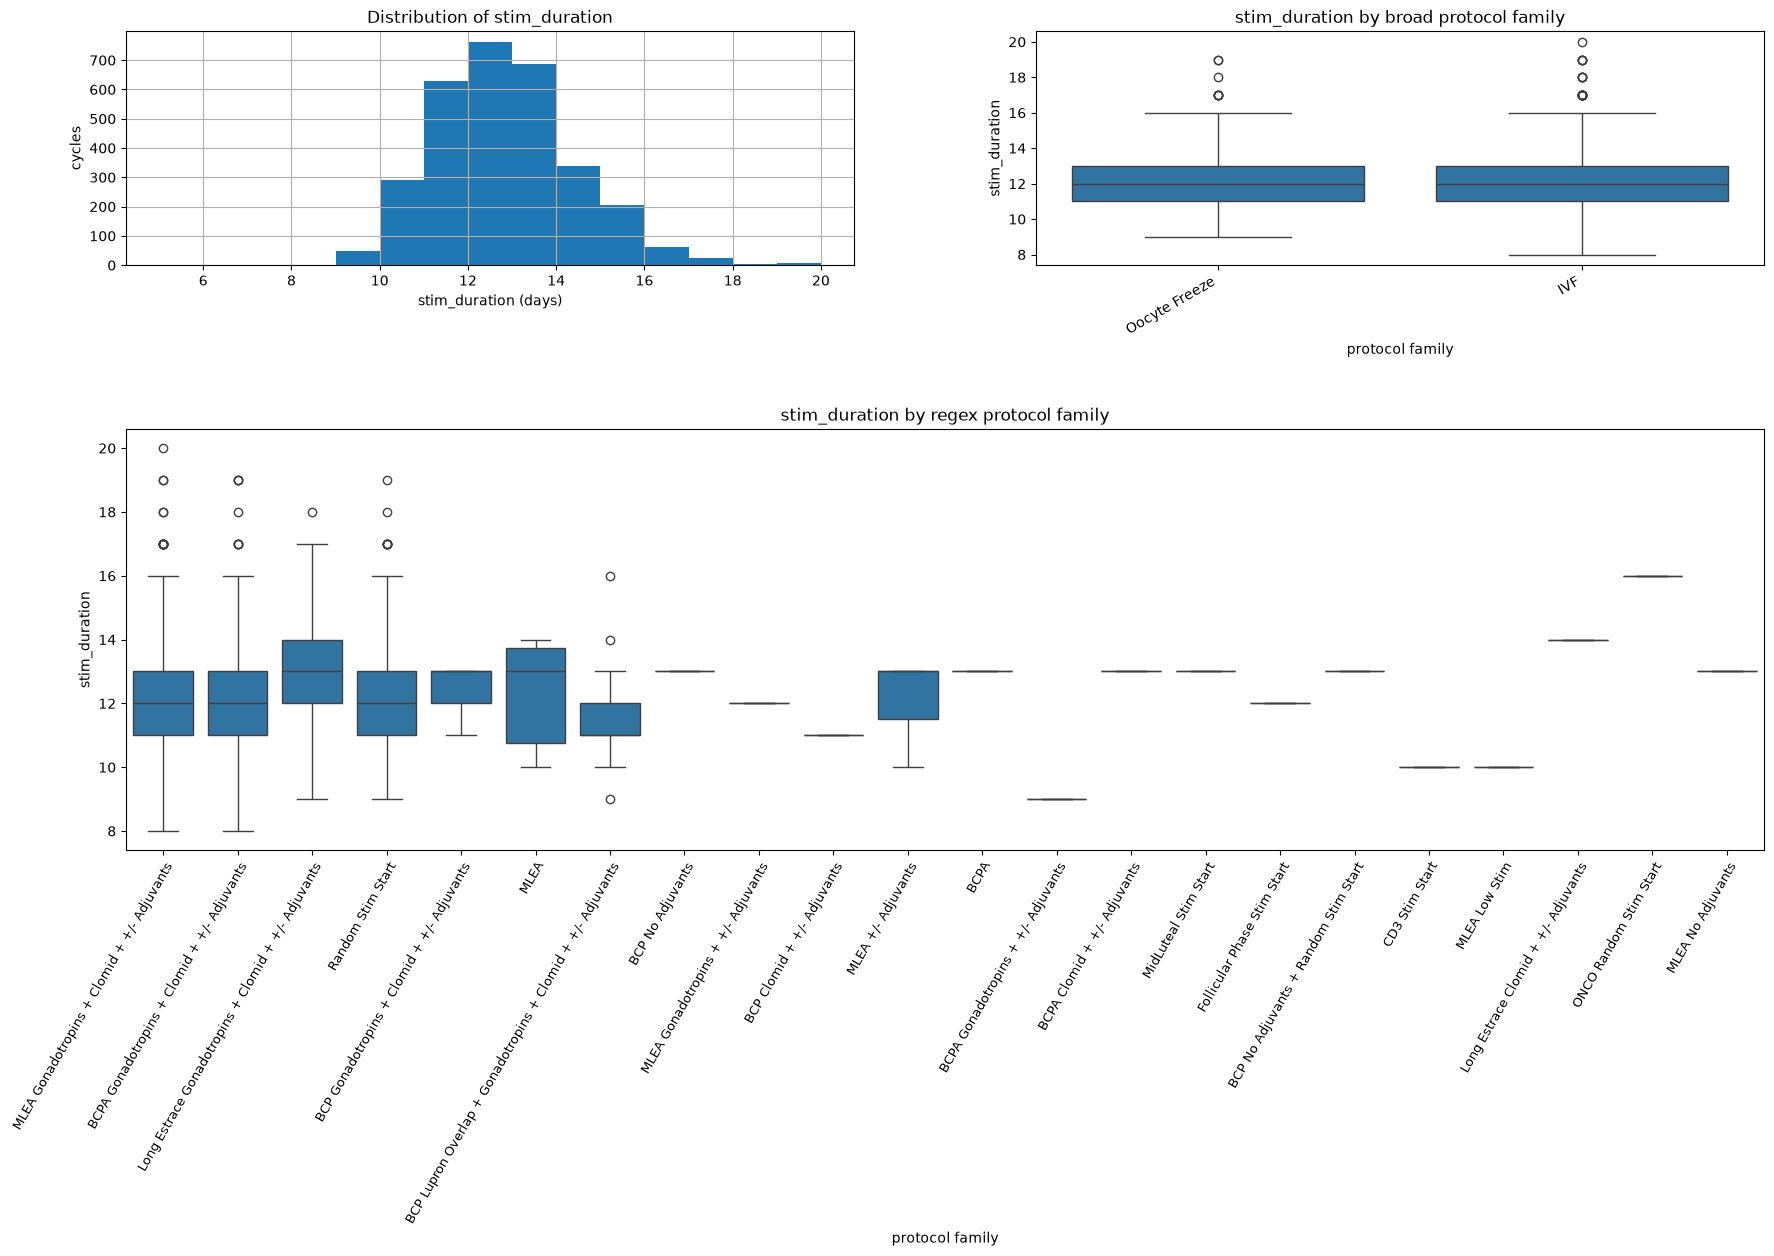

count    3062.000000
mean       12.349771
std         1.610606
min         8.000000
25%        11.000000
50%        12.000000
75%        13.000000
max        20.000000
Name: stim_duration, dtype: float64


In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Figure layout
# ============================================================

fig = plt.figure(figsize=(18, 13))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.8],
    hspace=0.5,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])   # top left
ax2 = fig.add_subplot(gs[0, 1])   # top right
ax3 = fig.add_subplot(gs[1, :])   # bottom, spans both columns


# ============================================================
# 1. Distribution of stim_duration
# ============================================================

df_cycle['stim_duration'].hist(
    bins=range(5, 21),
    ax=ax1
)

ax1.set_xlabel("stim_duration (days)")
ax1.set_ylabel("cycles")
ax1.set_title("Distribution of stim_duration")


# ============================================================
# 2. stim_duration by broad protocol family
# ============================================================

sns.boxplot(
    data=df_cycle,
    x='protocol_family_broad',
    y='stim_duration',
    ax=ax2
)

ax2.set_xlabel("protocol family")
ax2.set_ylabel("stim_duration")
ax2.set_title("stim_duration by broad protocol family")

plt.setp(
    ax2.get_xticklabels(),
    rotation=30,
    ha='right'
)


# ============================================================
# 3. stim_duration by regex protocol family
# ============================================================

sns.boxplot(
    data=df_cycle,
    x='protocol_family_regex',
    y='stim_duration',
    ax=ax3
)

ax3.set_xlabel("protocol family")
ax3.set_ylabel("stim_duration")
ax3.set_title("stim_duration by regex protocol family")

# Keep labels as ONE continuous string
# and rotate them so they don't overlap
plt.setp(
    ax3.get_xticklabels(),
    rotation=60,
    ha='right',
    rotation_mode='anchor',
    fontsize=9
)


# ============================================================
# Final layout adjustments
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.95,
    bottom=0.32
)

plt.show()


# ============================================================
# Summary statistics
# ============================================================

print(df_cycle['stim_duration'].describe())


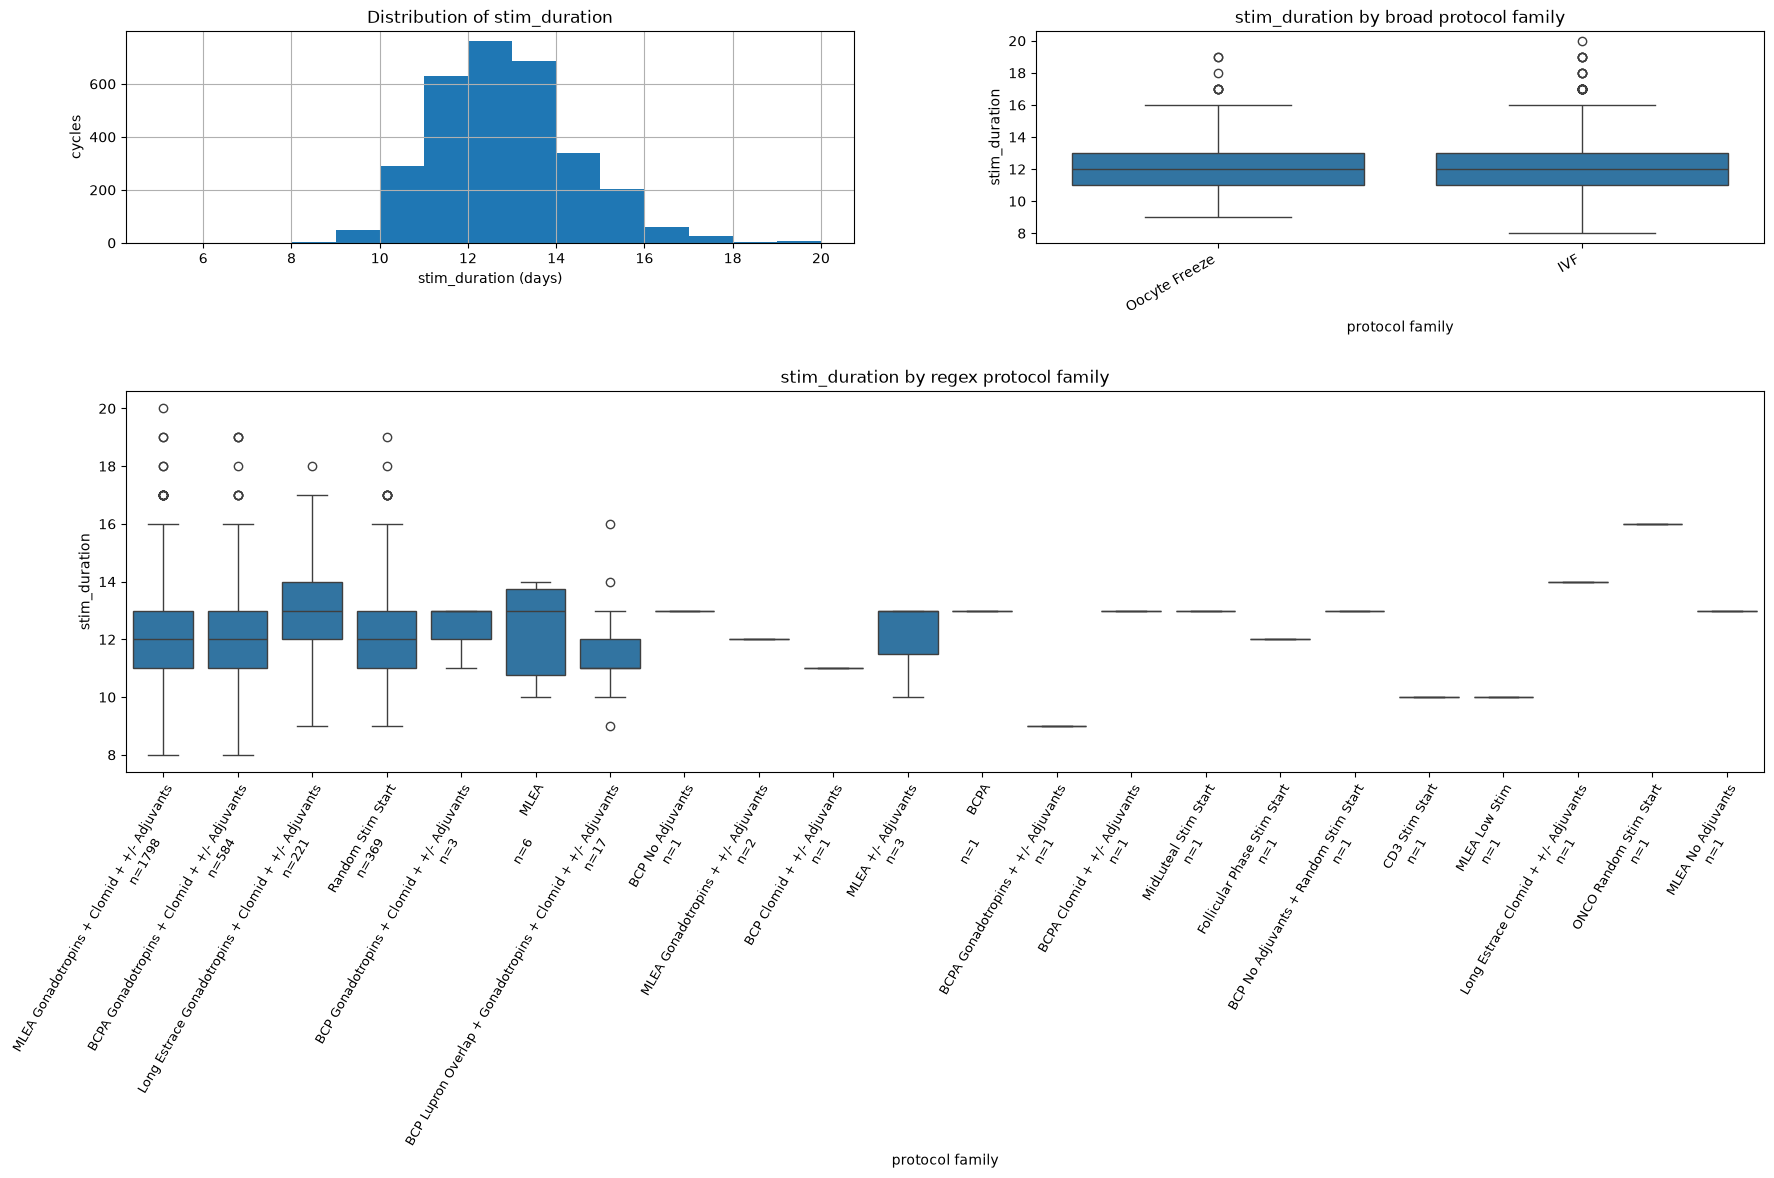

count    3062.000000
mean       12.349771
std         1.610606
min         8.000000
25%        11.000000
50%        12.000000
75%        13.000000
max        20.000000
Name: stim_duration, dtype: float64


In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Figure layout
# ============================================================

fig = plt.figure(figsize=(18, 13))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.8],
    hspace=0.5,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])


# ============================================================
# 1. Distribution of stim_duration
# ============================================================

df_cycle['stim_duration'].hist(
    bins=range(5, 21),
    ax=ax1
)

ax1.set_xlabel("stim_duration (days)")
ax1.set_ylabel("cycles")
ax1.set_title("Distribution of stim_duration")


# ============================================================
# 2. stim_duration by broad protocol family
# ============================================================

sns.boxplot(
    data=df_cycle,
    x='protocol_family_broad',
    y='stim_duration',
    ax=ax2
)

ax2.set_xlabel("protocol family")
ax2.set_ylabel("stim_duration")
ax2.set_title("stim_duration by broad protocol family")

plt.setp(
    ax2.get_xticklabels(),
    rotation=30,
    ha='right'
)


# ============================================================
# 3. stim_duration by regex protocol family
# ============================================================

sns.boxplot(
    data=df_cycle,
    x='protocol_family_regex',
    y='stim_duration',
    ax=ax3
)

ax3.set_xlabel("protocol family")
ax3.set_ylabel("stim_duration")
ax3.set_title("stim_duration by regex protocol family")


# ============================================================
# Add n for each regex protocol family
# ============================================================

counts = df_cycle['protocol_family_regex'].value_counts()

labels = ax3.get_xticklabels()

for i, label in enumerate(labels):
    category = label.get_text()
    n = counts.get(category, 0)

    # Put count underneath the category label
    ax3.text(
        i,
        -0.17,
        f"n={n}",
        transform=ax3.get_xaxis_transform(),
        ha='right',
        va='top',
        rotation=60,
        fontsize=9
    )


# Rotate category labels
plt.setp(
    labels,
    rotation=60,
    ha='right',
    rotation_mode='anchor',
    fontsize=9
)


# ============================================================
# Final layout
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.95,
    bottom=0.38
)

plt.show()


# ============================================================
# Summary statistics
# ============================================================

print(df_cycle['stim_duration'].describe())

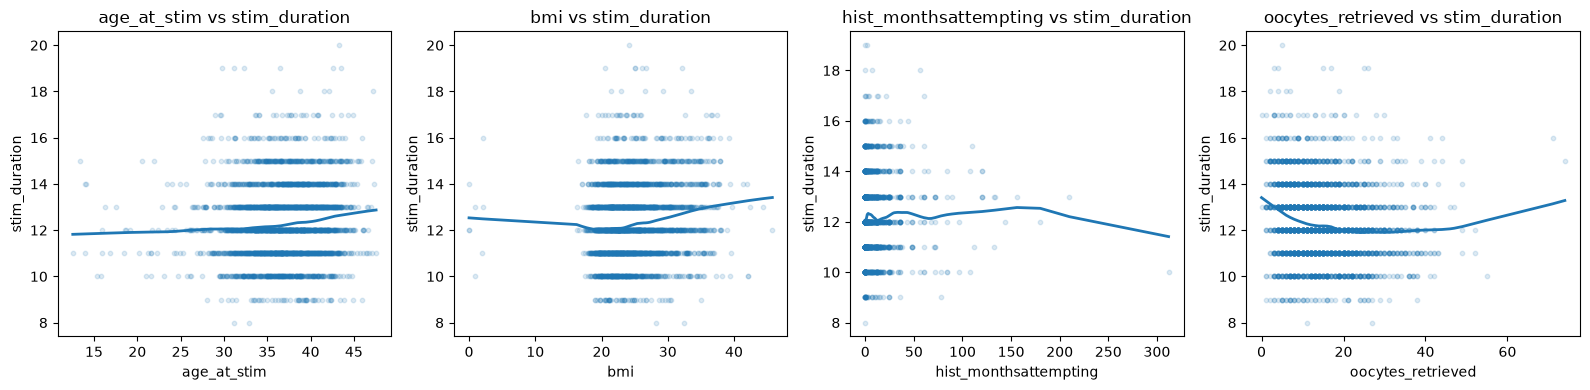

In [96]:
from statsmodels.nonparametric.smoothers_lowess import lowess

continuous = [
    'age_at_stim',
    'bmi',
    'hist_monthsattempting',
    'oocytes_retrieved'
]
continuous = [c for c in continuous if c in df_cycle.columns]

fig, axes = plt.subplots(
    1, len(continuous),
    figsize=(4 * len(continuous), 4)
)

for ax, c in zip(axes.flatten(), continuous):

    valid = df_cycle[[c, 'stim_duration']].dropna()

    # Individual observations
    ax.scatter(
        valid[c],
        valid['stim_duration'],
        alpha=0.15,
        s=10
    )

    # Smooth trend
    smooth = lowess(
        valid['stim_duration'],
        valid[c],
        frac=0.4,
        return_sorted=True
    )

    ax.plot(
        smooth[:, 0],
        smooth[:, 1],
        linewidth=2
    )

    ax.set_xlabel(c)
    ax.set_ylabel('stim_duration')
    ax.set_title(f"{c} vs stim_duration")

plt.tight_layout()
plt.show()

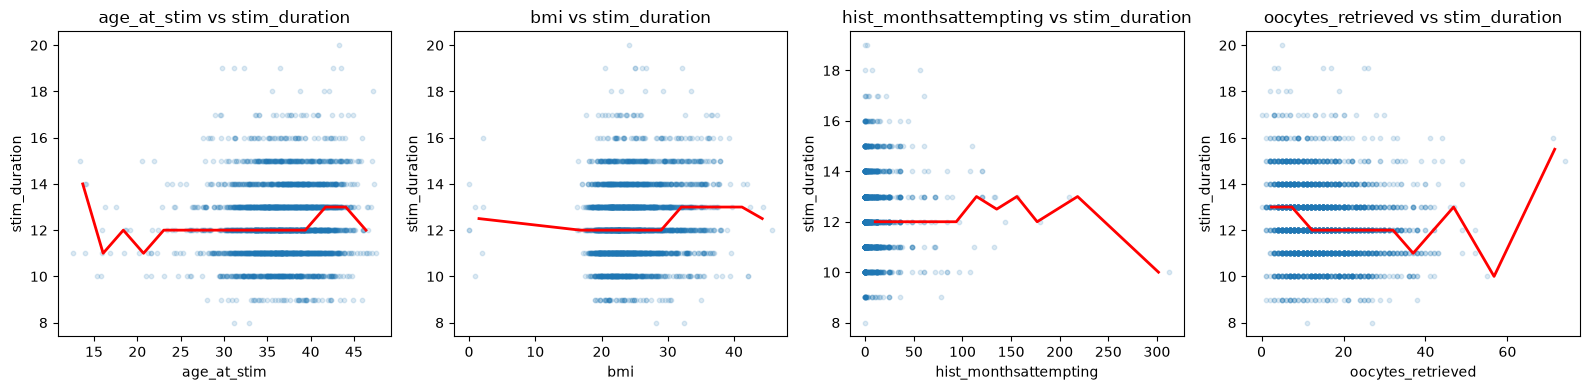


Correlation with stim_duration:
stim_duration            1.000000
bmi                      0.141757
age_at_stim              0.092948
hist_monthsattempting    0.006279
oocytes_retrieved       -0.137066
Name: stim_duration, dtype: float64


In [95]:
continuous = ['age_at_stim', 'bmi', 'hist_monthsattempting', 'oocytes_retrieved']
continuous = [c for c in continuous if c in df_cycle.columns]

fig, axes = plt.subplots(1, len(continuous), figsize=(4*len(continuous), 4))
for ax, c in zip(axes.flatten(), continuous):
    valid = df_cycle[[c, 'stim_duration']].dropna()
    ax.scatter(valid[c], valid['stim_duration'], alpha=0.15, s=10)
    # Rolling median as a trend line
    binned = valid.assign(bin=pd.cut(valid[c], bins=15)).groupby('bin', observed=True)
    med = binned['stim_duration'].median()
    ax.plot([b.mid for b in med.index], med.values, 'r-', linewidth=2)
    ax.set_xlabel(c)
    ax.set_ylabel('stim_duration')
    ax.set_title(f"{c} vs stim_duration")
plt.tight_layout()
plt.show()

# Pearson correlations with target
print("\nCorrelation with stim_duration:")
print(df_cycle[continuous + ['stim_duration']].corr()['stim_duration']
      .sort_values(ascending=False))

C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\2444806942.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels, rotation=30, ha='right')
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\2444806942.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels, rotation=30, ha='right')
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\2444806942.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels, rotation=30, ha='right')
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\2444806942.py:12: UserWarning: set_ticklabels() should only be u

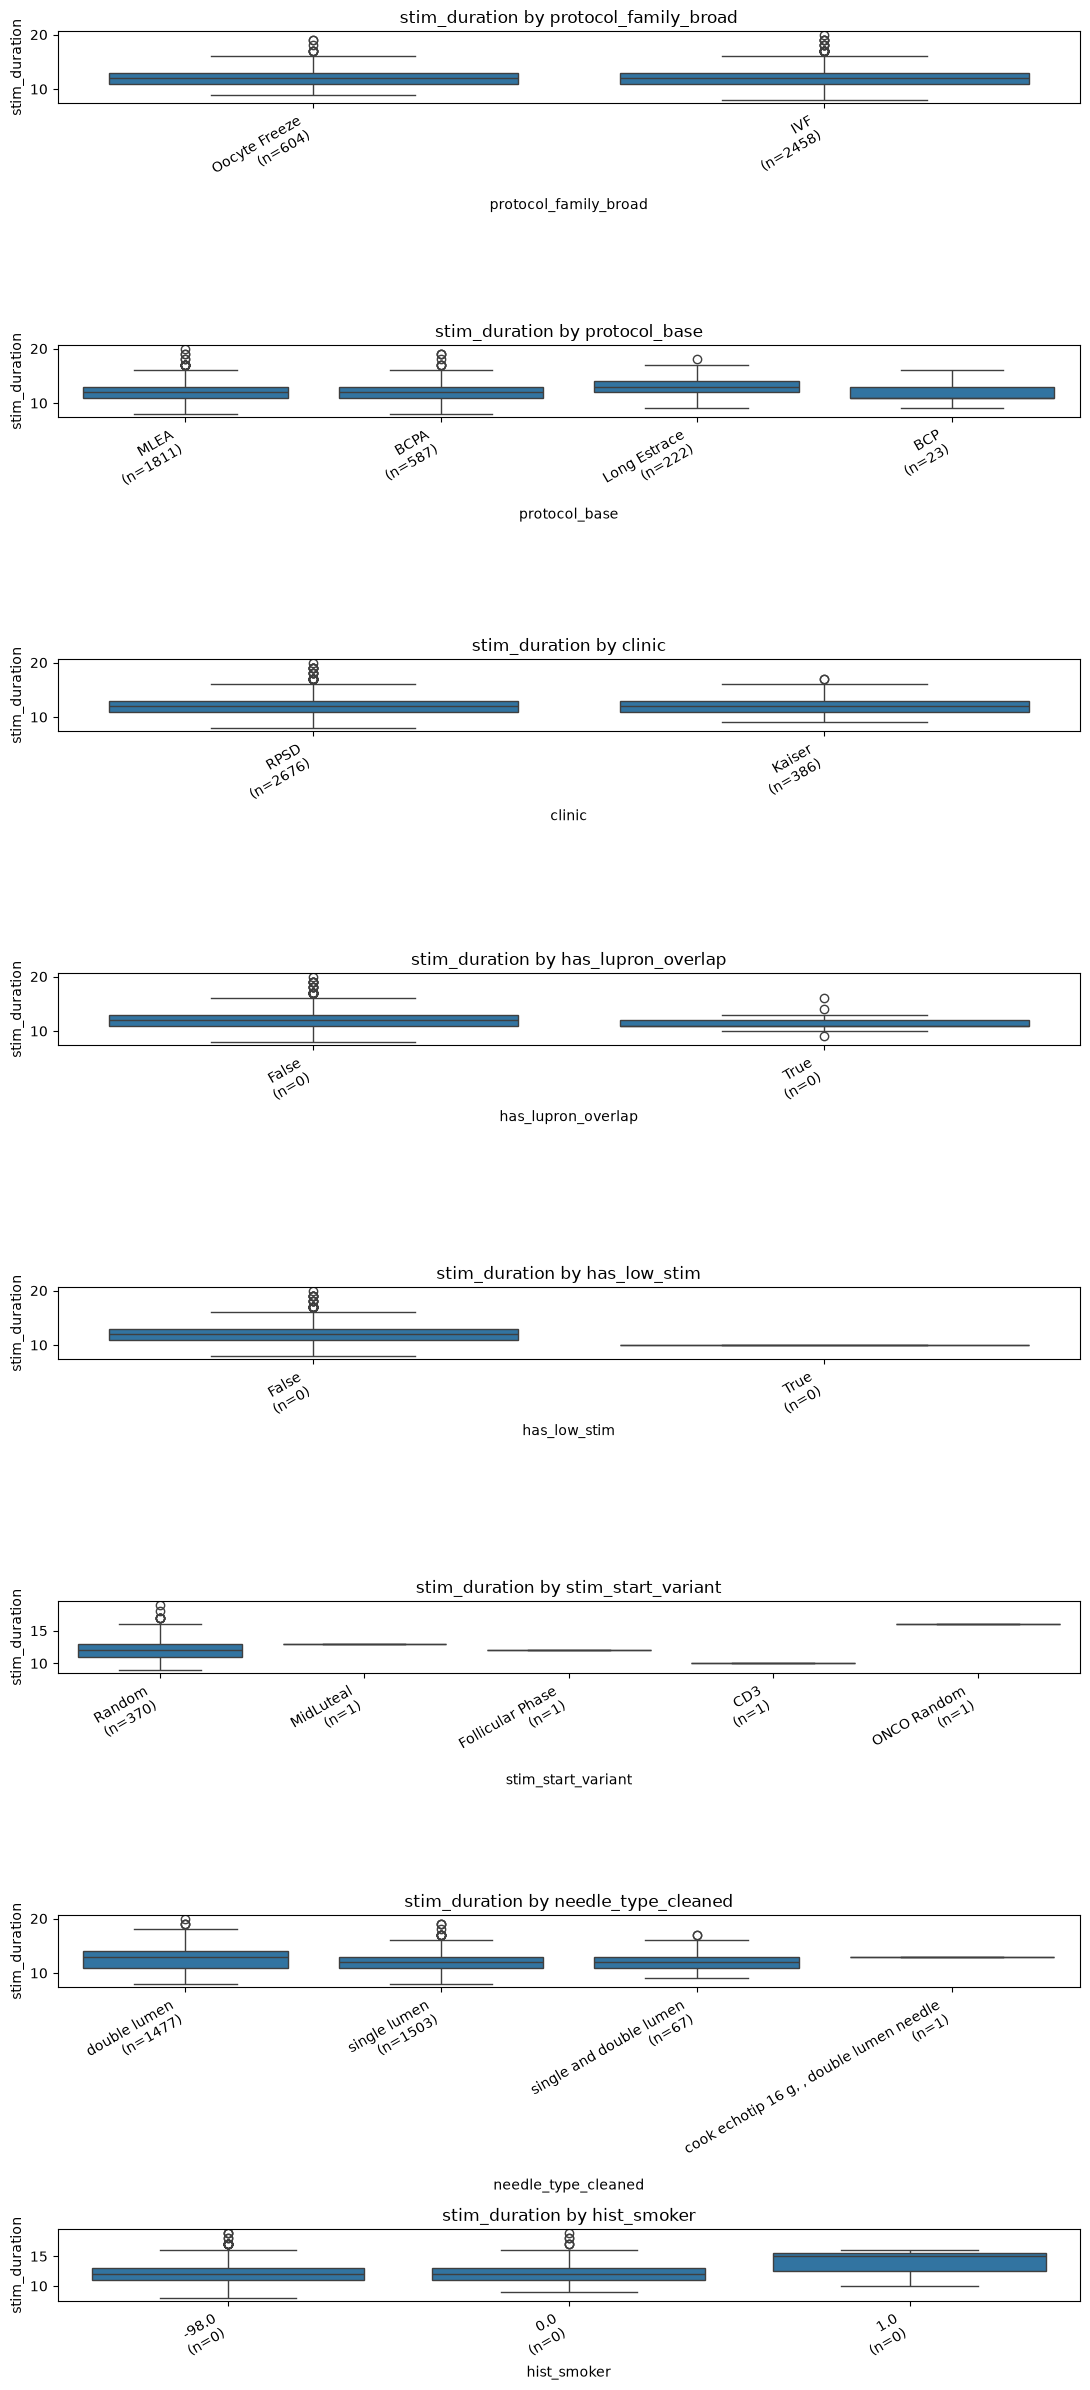

In [107]:
categorical = ['protocol_family_broad', 'protocol_base', 'clinic',
               'has_lupron_overlap', 'has_low_stim', 'stim_start_variant',
               'needle_type_cleaned', 'hist_smoker']
categorical = [c for c in categorical if c in df_cycle.columns]

fig, axes = plt.subplots(len(categorical), 1, figsize=(11, 3*len(categorical)))
for ax, c in zip(axes.flatten(), categorical):
    sns.boxplot(data=df_cycle, x=c, y='stim_duration', ax=ax)
    counts = df_cycle[c].value_counts()
    labels = [f"{t.get_text()}\n(n={counts.get(t.get_text(), 0)})"
              for t in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_title(f"stim_duration by {c}")
plt.tight_layout()
plt.show()

C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\619301771.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\619301771.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\619301771.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\619301771.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks m

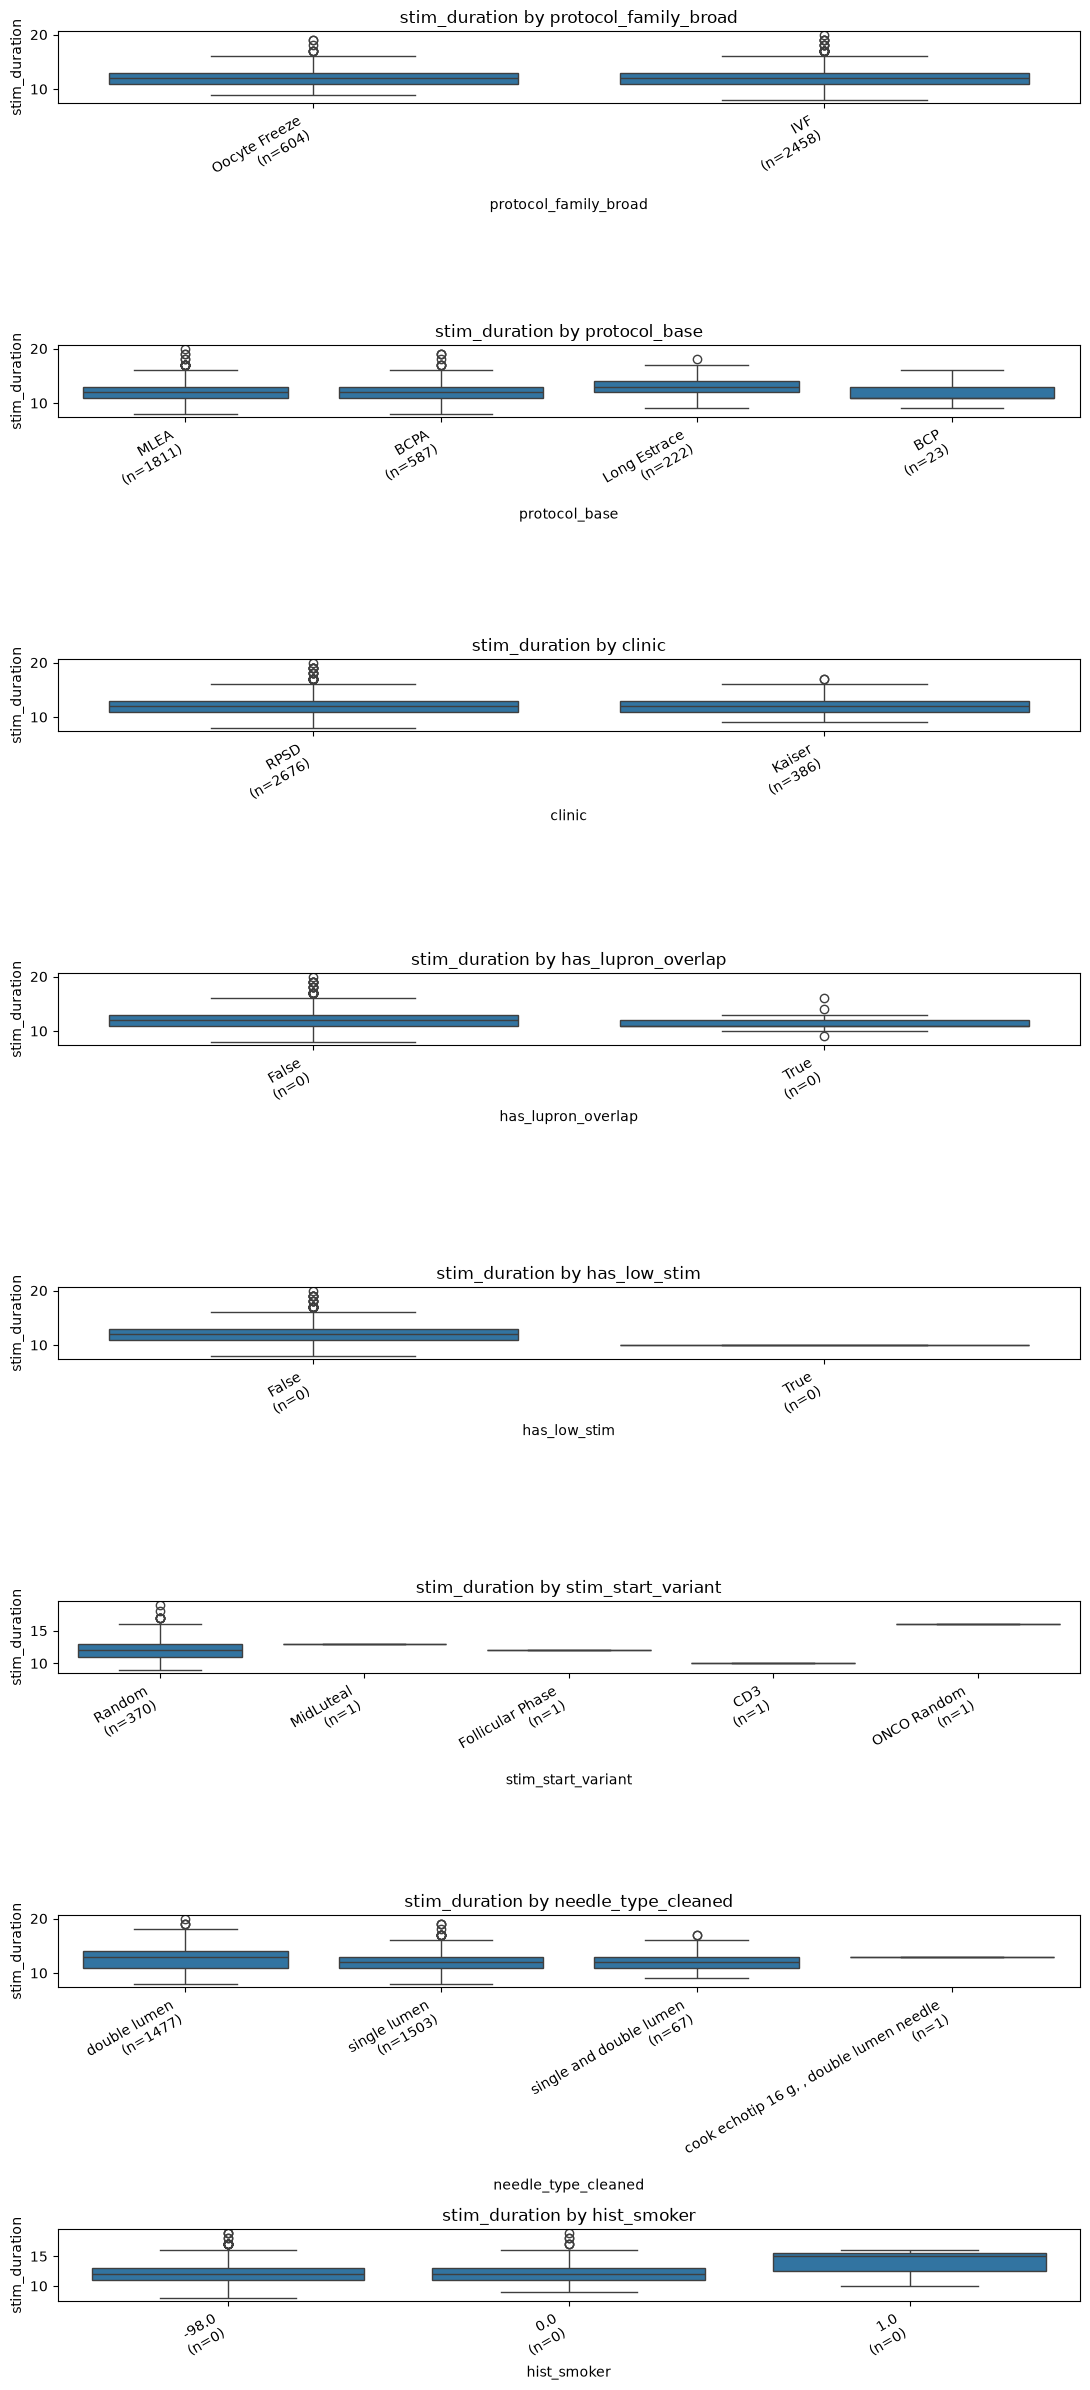

,variable,group1,group2,n1,n2,mean1,mean2,t_stat,p_value,p_adjusted,significant
0,protocol_family_broad,Oocyte Freeze,IVF,604,2458,12.205298,12.385273,-2.451392,1.441614e-02,NaN,False
1,protocol_base,MLEA,BCPA,1811,587,12.500828,11.758092,9.736664,2.080989e-21,NaN,False
2,protocol_base,MLEA,Long Estrace,1811,222,12.500828,12.990991,-4.617998,5.906725e-06,NaN,False
3,protocol_base,MLEA,BCP,1811,23,12.500828,11.782609,2.187229,3.937648e-02,NaN,False
4,protocol_base,BCPA,Long Estrace,587,222,11.758092,12.990991,-10.229181,3.800890e-22,NaN,False
5,protocol_base,BCPA,BCP,587,23,11.758092,11.782609,-0.073558,9.419740e-01,NaN,False
6,protocol_base,Long Estrace,BCP,222,23,12.990991,11.782609,3.539787,1.515100e-03,NaN,False
7,clinic,RPSD,Kaiser,2676,386,12.345665,12.378238,-0.396327,6.920242e-01,NaN,False
8,has_lupron_overlap,False,True,3045,17,12.354023,11.588235,1.855122,8.191349e-02,NaN,False
9,has_low_stim,False,True,3061,1,12.350539,10.000000,NaN,NaN,NaN,False


In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from itertools import combinations
from statsmodels.stats.multitest import multipletests

categorical = [
    'protocol_family_broad',
    'protocol_base',
    'clinic',
    'has_lupron_overlap',
    'has_low_stim',
    'stim_start_variant',
    'needle_type_cleaned',
    'hist_smoker'
]

categorical = [c for c in categorical if c in df_cycle.columns]

# Store all t-test results here
ttest_results = []

fig, axes = plt.subplots(
    len(categorical), 1,
    figsize=(11, 3 * len(categorical))
)

# Make sure axes is iterable if there is only one categorical variable
if len(categorical) == 1:
    axes = [axes]

for ax, c in zip(axes, categorical):

    # Drop missing values for this variable
    temp = df_cycle[[c, 'stim_duration']].dropna()

    # Boxplot
    sns.boxplot(
        data=temp,
        x=c,
        y='stim_duration',
        ax=ax
    )

    # Counts
    counts = temp[c].value_counts()

    labels = [
        f"{t.get_text()}\n(n={counts.get(t.get_text(), 0)})"
        for t in ax.get_xticklabels()
    ]

    ax.set_xticklabels(
        labels,
        rotation=30,
        ha='right'
    )

    ax.set_title(f"stim_duration by {c}")

    # Get groups
    groups = temp[c].unique()

    # Pairwise t-tests
    for group1, group2 in combinations(groups, 2):

        values1 = temp.loc[
            temp[c] == group1,
            'stim_duration'
        ]

        values2 = temp.loc[
            temp[c] == group2,
            'stim_duration'
        ]

        # Welch's independent t-test
        t_stat, p_value = ttest_ind(
            values1,
            values2,
            equal_var=False
        )

        ttest_results.append({
            'variable': c,
            'group1': group1,
            'group2': group2,
            'n1': len(values1),
            'n2': len(values2),
            'mean1': values1.mean(),
            'mean2': values2.mean(),
            't_stat': t_stat,
            'p_value': p_value
        })

plt.tight_layout()
plt.show()


# Convert results to DataFrame
ttest_results = pd.DataFrame(ttest_results)

# Correct for multiple comparisons
ttest_results['p_adjusted'] = multipletests(
    ttest_results['p_value'],
    method='fdr_bh'
)[1]

# Flag significant results
ttest_results['significant'] = (
    ttest_results['p_adjusted'] < 0.05
)

# Sort by adjusted p-value
ttest_results = ttest_results.sort_values('p_adjusted')

ttest_results

C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\3099390435.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\3099390435.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\3099390435.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_40216\3099390435.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, tic

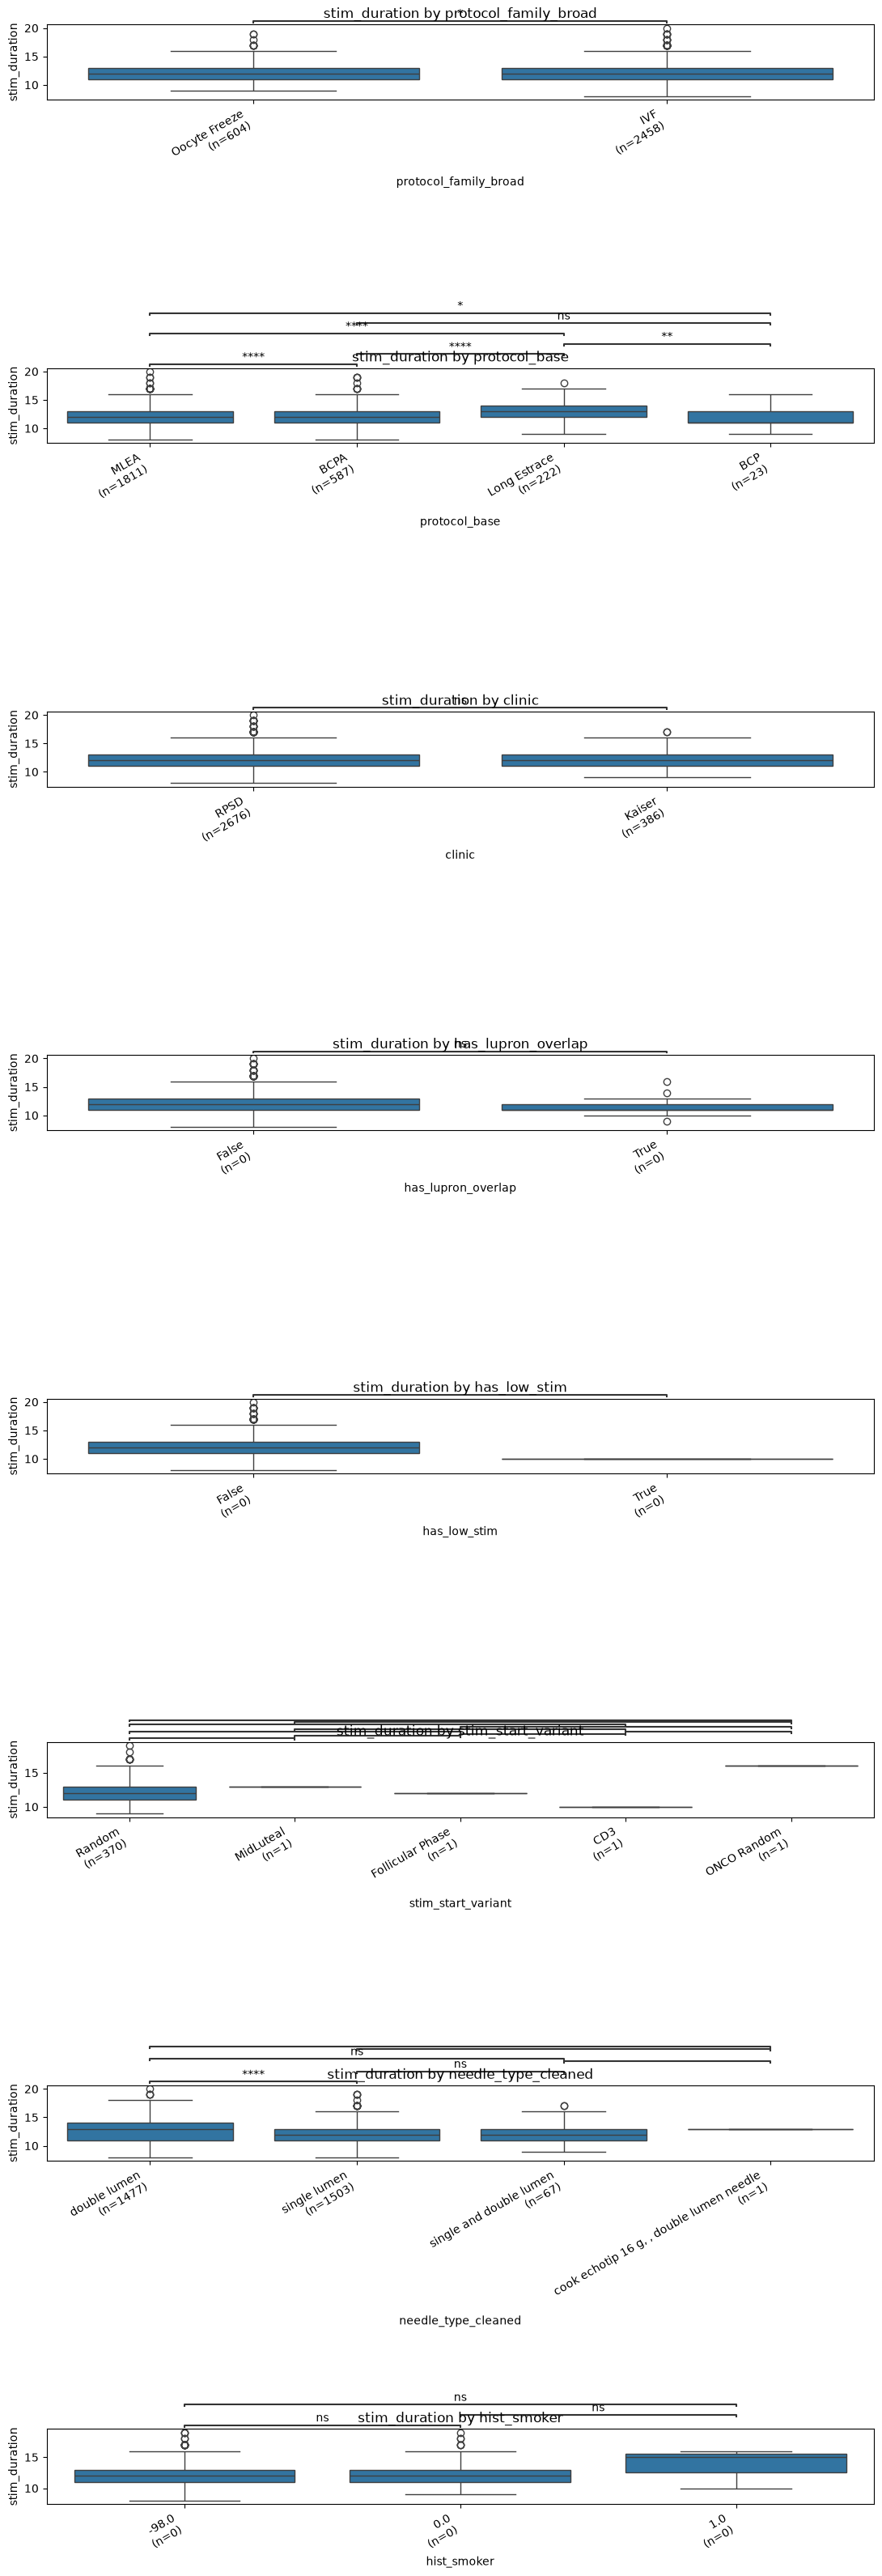

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statannotations.Annotator import Annotator

categorical = [
    'protocol_family_broad',
    'protocol_base',
    'clinic',
    'has_lupron_overlap',
    'has_low_stim',
    'stim_start_variant',
    'needle_type_cleaned',
    'hist_smoker'
]

categorical = [c for c in categorical if c in df_cycle.columns]

fig, axes = plt.subplots(
    len(categorical),
    1,
    figsize=(11, 4 * len(categorical))
)

if len(categorical) == 1:
    axes = [axes]

for ax, c in zip(axes, categorical):

    # Remove missing values
    temp = df_cycle[[c, 'stim_duration']].dropna()

    # Boxplot
    sns.boxplot(
        data=temp,
        x=c,
        y='stim_duration',
        ax=ax
    )

    # Counts
    counts = temp[c].value_counts()

    labels = [
        f"{t.get_text()}\n(n={counts.get(t.get_text(), 0)})"
        for t in ax.get_xticklabels()
    ]

    ax.set_xticklabels(
        labels,
        rotation=30,
        ha='right'
    )

    ax.set_title(f"stim_duration by {c}")

    # Get groups
    groups = list(temp[c].unique())

    # Only do pairwise comparisons if there are at least 2 groups
    if len(groups) >= 2:

        # All pairwise combinations
        pairs = [
            (groups[i], groups[j])
            for i in range(len(groups))
            for j in range(i + 1, len(groups))
        ]

        # Add statistical annotations
        annotator = Annotator(
            ax,
            pairs,
            data=temp,
            x=c,
            y='stim_duration'
        )

        annotator.configure(
            test='t-test_welch',
            text_format='star',
            comparisons_correction='fdr_bh',
            loc='outside',
            verbose=0
        )

        annotator.apply_and_annotate()

plt.tight_layout()
plt.show()

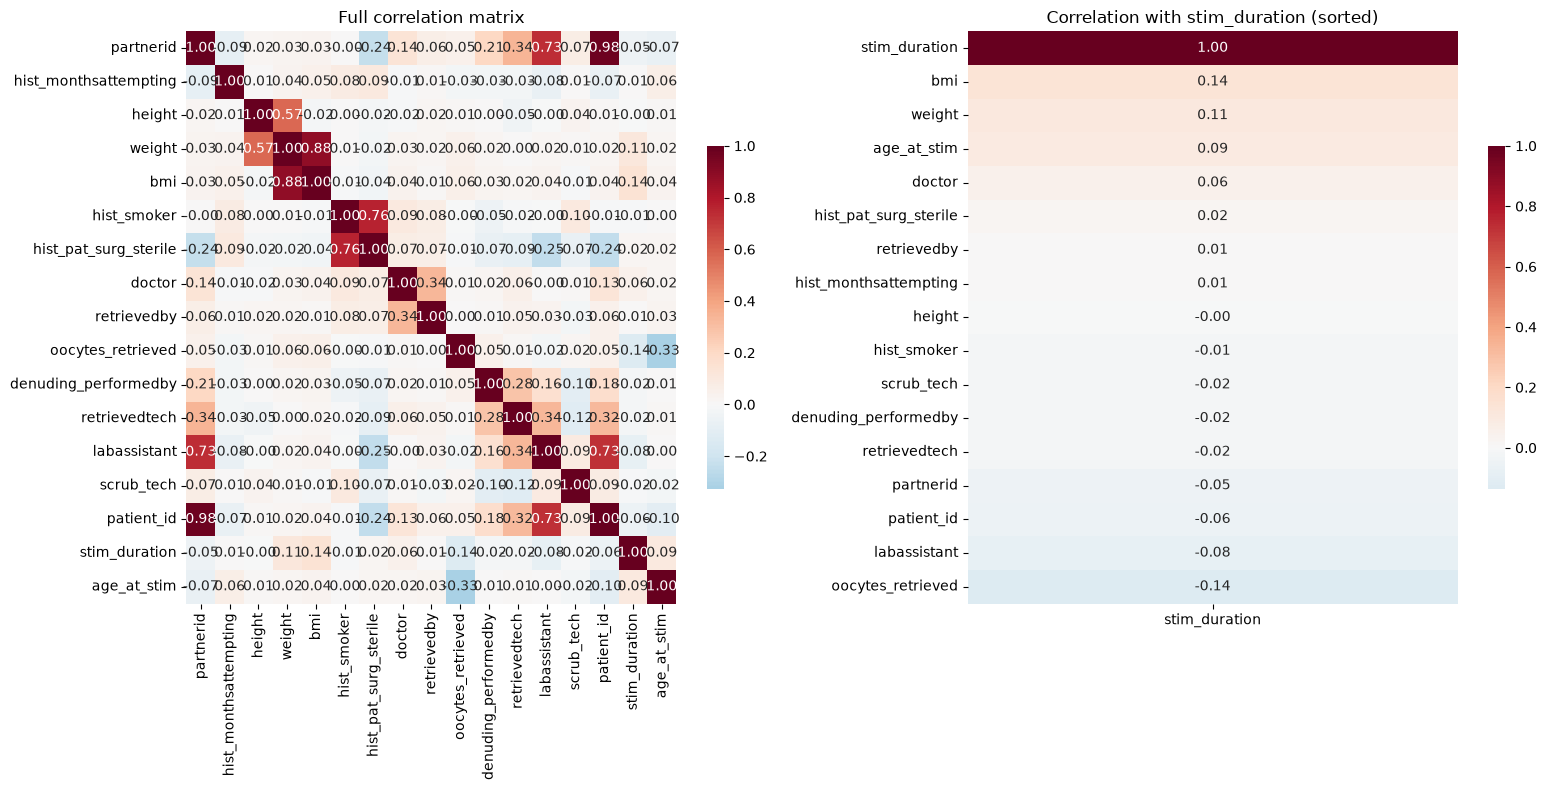

In [108]:
numeric_cols = df_cycle.select_dtypes(include='number').columns.tolist()
# Exclude IDs and things that aren't real features
exclude = ['cycleid', 'patid', 'id', 'accession_number', 'sart_id']
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr = df_cycle[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
# Full correlation matrix
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], cbar_kws={'shrink': 0.6})
axes[0].set_title("Full correlation matrix")

# Just correlations with stim_duration, sorted
corr_stim = corr[['stim_duration']].sort_values('stim_duration', ascending=False)
sns.heatmap(corr_stim, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], cbar_kws={'shrink': 0.6})
axes[1].set_title("Correlation with stim_duration (sorted)")
plt.tight_layout()
plt.show()

R²  (patient-grouped 5-fold CV): 0.040 ± 0.022
MAE (patient-grouped 5-fold CV): 1.24 ± 0.03 days

Top features:
              feature  importance      std
                  bmi    0.131223 0.004751
    oocytes_retrieved    0.090412 0.005396
        protocol_base    0.078492 0.006654
          age_at_stim    0.072153 0.003011
hist_monthsattempting    0.032312 0.002112
               doctor    0.029940 0.002538
    has_gonadotropins    0.024996 0.002343
  needle_type_cleaned    0.012890 0.001173
hist_pat_surg_sterile    0.009296 0.001510
          hist_smoker    0.003266 0.000435
protocol_family_broad    0.002631 0.000749
               clinic    0.002519 0.000436
   stim_start_variant    0.001853 0.000559
           has_clomid    0.001564 0.000411
   has_lupron_overlap    0.001217 0.000470


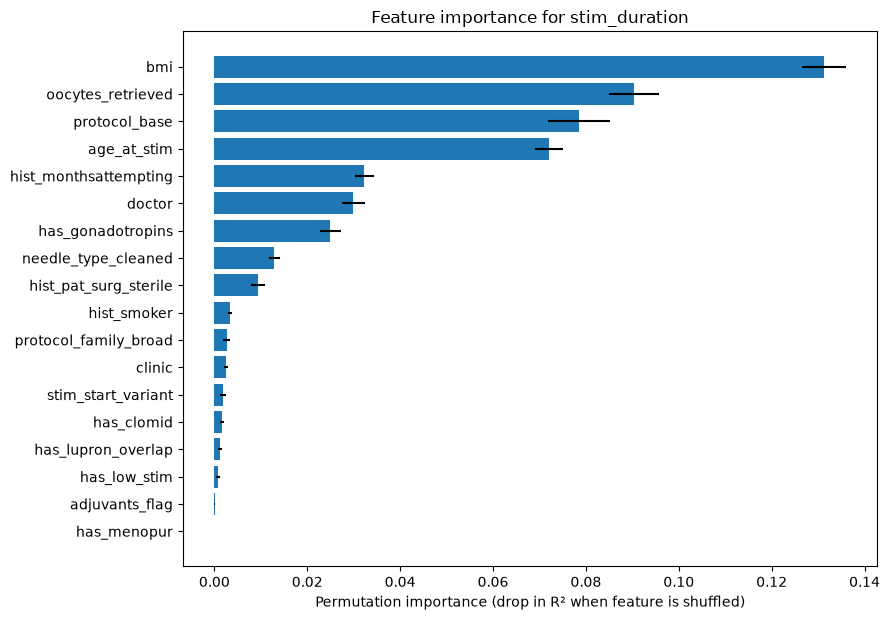

In [109]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OrdinalEncoder

features_num = ['age_at_stim', 'bmi', 'hist_monthsattempting', 'oocytes_retrieved']
features_bool = ['has_lupron_overlap', 'has_gonadotropins', 'has_clomid',
                 'has_menopur', 'has_low_stim', 'hist_smoker',
                 'hist_pat_surg_sterile']
features_cat = ['protocol_family_broad', 'protocol_base', 'clinic',
                'stim_start_variant', 'needle_type_cleaned',
                'adjuvants_flag', 'doctor']

features_num  = [c for c in features_num  if c in df_cycle.columns]
features_bool = [c for c in features_bool if c in df_cycle.columns]
features_cat  = [c for c in features_cat  if c in df_cycle.columns]

X = df_cycle[features_num + features_bool + features_cat].copy()

# Encode categoricals as ordinals (fine for tree models)
for c in features_cat:
    X[c] = X[c].astype(str)
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[features_cat] = enc.fit_transform(X[features_cat])

# Cast bools to int, fill numeric NaN with median
for c in features_bool:
    X[c] = X[c].astype(float)
X = X.fillna(X.median(numeric_only=True))

y = df_cycle['stim_duration']
groups = df_cycle['patid']

model = GradientBoostingRegressor(n_estimators=500, max_depth=3,
                                  learning_rate=0.03, random_state=0)

gkf = GroupKFold(n_splits=5)
r2  = cross_val_score(model, X, y, groups=groups, cv=gkf, scoring='r2')
mae = -cross_val_score(model, X, y, groups=groups, cv=gkf,
                       scoring='neg_mean_absolute_error')
print(f"R²  (patient-grouped 5-fold CV): {r2.mean():.3f} ± {r2.std():.3f}")
print(f"MAE (patient-grouped 5-fold CV): {mae.mean():.2f} ± {mae.std():.2f} days")

# Fit on full data for importance analysis
model.fit(X, y)
r = permutation_importance(model, X, y, n_repeats=30, random_state=0, n_jobs=-1)
imp = (pd.DataFrame({'feature': X.columns,
                     'importance': r.importances_mean,
                     'std': r.importances_std})
         .sort_values('importance', ascending=False))
print("\nTop features:")
print(imp.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(9, 0.35*len(imp)))
plt.barh(imp['feature'], imp['importance'], xerr=imp['std'])
plt.gca().invert_yaxis()
plt.xlabel("Permutation importance (drop in R² when feature is shuffled)")
plt.title("Feature importance for stim_duration")
plt.tight_layout()
plt.show()

In [ ]:

from sklearn.inspection import PartialDependenceDisplay

top_features = imp['feature'].head(6).tolist()
top_indices = [list(X.columns).index(f) for f in top_features]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
PartialDependenceDisplay.from_estimator(model, X, top_indices, ax=axes,
                                        feature_names=list(X.columns))
plt.tight_layout()
plt.show()

In [ ]:
# Prospective (pre-stim features only — could actually predict future cycles)
prospective_features = [f for f in X.columns
                        if f not in ['oocytes_retrieved']]

# Retrospective (includes post-stim signals like oocyte count)
retrospective_features = list(X.columns)

for label, feats in [('Prospective (pre-stim only)', prospective_features),
                     ('Retrospective (all features)', retrospective_features)]:
    r2 = cross_val_score(model, X[feats], y, groups=groups, cv=gkf, scoring='r2')
    print(f"{label:35s}  R² = {r2.mean():.3f} ± {r2.std():.3f}")

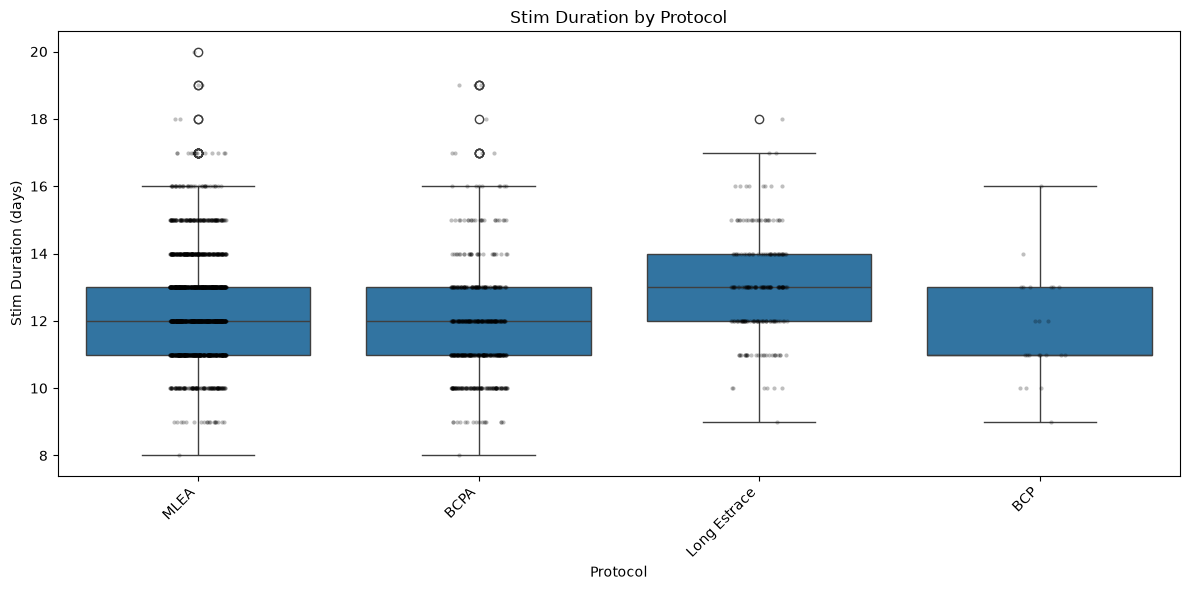

In [110]:
# showing stim_duration by protocol_base
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_cycle,
    x="protocol_base",
    y="stim_duration"
)

sns.stripplot(
    data=df_cycle,
    x="protocol_base",
    y="stim_duration",
    color="black",
    alpha=0.25,
    size=3,
    jitter=True
)

plt.xlabel("Protocol")
plt.ylabel("Stim Duration (days)")
plt.title("Stim Duration by Protocol")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

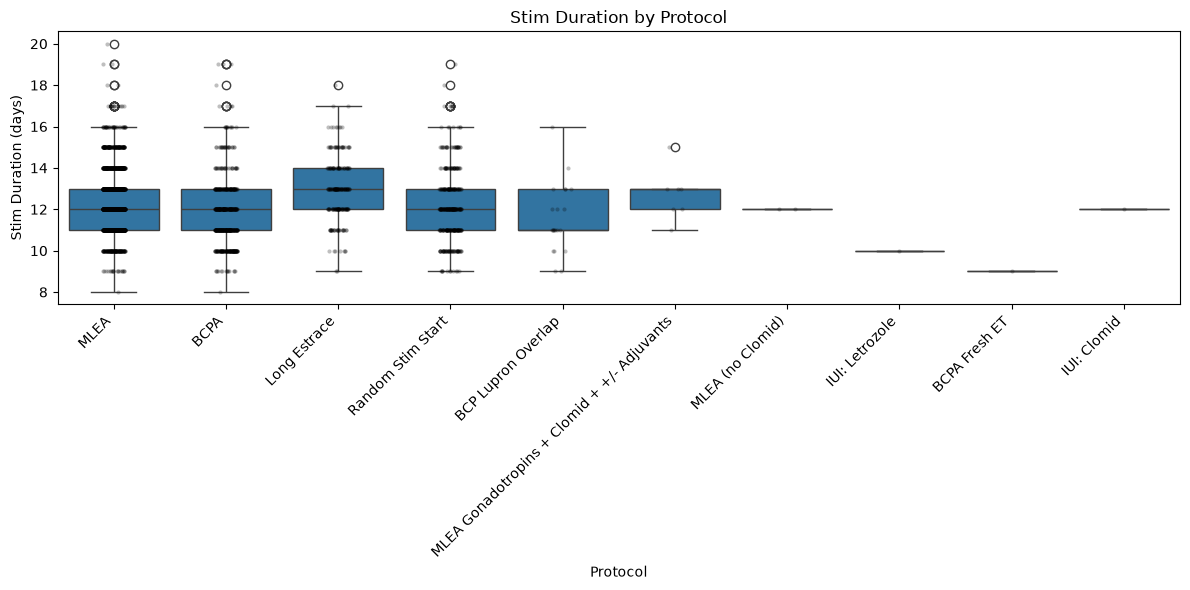

In [112]:
# showing stim_duration by protocol_family
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_cycle,
    x="protocol_family",
    y="stim_duration"
)

sns.stripplot(
    data=df_cycle,
    x="protocol_family",
    y="stim_duration",
    color="black",
    alpha=0.25,
    size=3,
    jitter=True
)

plt.xlabel("Protocol")
plt.ylabel("Stim Duration (days)")
plt.title("Stim Duration by Protocol")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [111]:
display(df_cycle)


,cycleid,patid,partnerid,sart_id,status,closed,cycletype,cycle_name,cycle_type,clinic,protocol_family,protocol_detail,protocol_family_broad,protocol_family_uuid,protocol_family_regex,adjuvants,cyclestart,cycleend,end_reason,event_labels,plan_treatment,hist_monthsattempting,main_note,height,weight,bmi,hist_smoker,hist_pat_surg_sterile,doctor,art_reason,id,retrieved,retrievedby,oocytes_retrieved,complication,note,denuding_performed,denuding_performedby,retrievedtech,labassistant,scrub_tech,crna,needle_type,duration,accession_number,needle_type_cleaned,patient_id,account,dob,stim_duration,age_at_stim,donor_type,uuid_regex_agreement,classification_status,conversion,conversion_targets,original_cycle,freeze_all,unstimulated,stim_start_variant,is_ivf,is_fet,is_iui,is_tic,is_tdi,is_oocyte_freeze,is_oocyte_thaw,is_embryo_thaw,is_embryo_freeze,is_mock,is_spontaneous,is_third_party,is_intended_parent,is_recipient,is_gc,is_egg_donor,is_donor_embryo,is_reciprocal,is_compassionate,is_autologous,is_kaiser,protocol_base,has_lupron_overlap,has_gonadotropins,has_clomid,has_letrozole,has_menopur,has_low_stim,adjuvants_flag,fet_medication
0,4697acca-fe95-4e97-9a06-adc889b328ec,71089,NaN,n_15829,Completed,True,5cf37237-dd8c-4bcc-ae5e-3da7717a21cb,Oocyte Freeze Cycle - Autologous: MLEA Gonadot...,Oocyte Freeze,RPSD,MLEA,MLEA Gonadotropins +/- Clomid +/- +/- Adjuvants,Oocyte Freeze,MLEA,MLEA Gonadotropins + Clomid + +/- Adjuvants,"['Gonadotropins', 'Clomid', '+/- Adjuvants']",2025-10-24,11/11/2025,NaN,NaN,02672e1f-371b-433a-be83-8664dfe7412d,0.0,Lab Plan: Oocyte Vitrification for social fert...,177.80,72.574866,22.96,0.0,-1.0,1,ARTReason_7=on,a5ce1e7a-0b71-4276-be79-c1026e76e545,2025-11-06 09:13:00,3.0,12.0,NaN,NaN,2025-11-06 11:30:00-08,37.0,31.0,3279.0,285.0,Leann Johnson,double lumen needle,45,25-967,double lumen,71089,47734,1989-07-11,13.0,36.287474,Autologous,True,OK,False,None,None,False,False,NaN,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,MLEA,False,True,True,False,False,False,+/-,None
1,653730ec-fedf-4033-bb84-565d62fd7f18,58055,NaN,n_12418,Completed,True,ac36dd51-7809-4975-83de-48cda51987f5,Oocyte Freeze Cycle - Autologous: MLEA Gonadot...,Oocyte Freeze,RPSD,BCPA,BCPA Gonadotropins +/- Clomid +/- +/- Adjuvants,Oocyte Freeze,BCPA,MLEA Gonadotropins + Clomid + +/- Adjuvants,"['Gonadotropins', 'Clomid', '+/- Adjuvants']",2024-10-24,1/9/2025,NaN,NaN,02672e1f-371b-433a-be83-8664dfe7412d,0.0,Lab Plan: Oocyte Vitrification for social fert...,152.40,46.266477,19.92,-98.0,-98.0,3,ARTReason_7=on,3921806f-a0d0-467c-9661-07a3d3ff7f15,2024-11-04 07:34:00,89.0,31.0,NaN,verified by MMA,2024-11-04 09:48:00-08,39.0,309.0,2487.0,1366.0,Leann Johnson,cook echotip 16 g,12,24-859,single lumen,58055,34700,1988-09-22,11.0,36.087611,Autologous,False,REVIEW: UUID/regex mismatch,False,None,None,False,False,NaN,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,MLEA,False,True,True,False,False,False,+/-,None
2,62dde156-7a0e-4b7b-b4f5-0137ebd05336,53768,53769.0,n_9969,Completed,True,5cf37237-dd8c-4bcc-ae5e-3da7717a21cb,IVF: Freeze All - Autologous: MLEA Gonadotropi...,IVF Freeze-All,RPSD,MLEA,MLEA Gonadotropins +/- Clomid +/- +/- Adjuvants,IVF,MLEA,MLEA Gonadotropins + Clomid + +/- Adjuvants,"['Gonadotropins', 'Clomid', '+/- Adjuvants']",2024-03-01,4/5/2024,NaN,NaN,4e625189-d13b-4ca1-9f4d-463506ae7a5f,12.0,"Lab Plan: ICSI with ZyMot, CC, AH, PGT-A with ...",162.56,69.853308,26.43,-98.0,-98.0,10,ARTReason_6=on&ARTReason_6_DimOv=on&ARTReason_...,9542f08a-0165-4ffa-aa4f-b9f969e69fa1,2024-03-14 11:03:00,286.0,9.0,NaN,NaN,2024-03-14 15:01:00-07,31.0,39.0,32.0,1366.0,Leann Johnson,double lumen needle,36,K24-060,double lumen,53768,30413,1981-10-04,13.0,42.406571,Autologous,True,OK,False,None,None,True,False,NaN,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,T

In [74]:
# Filter to physiologically impossible BMI values
high_bmi = merged_df[merged_df['bmi'] > 60]

print(f"Rows with BMI > 60: {len(high_bmi)}")
print(f"Unique patients affected: {high_bmi['patid'].nunique()}")
print(f"\nBMI value distribution:")
print(high_bmi['bmi'].describe())

# Show the offending rows with the relevant columns
high_bmi[['patid', 'cycleid', 'height', 'weight', 'bmi',
          'age_at_stim', 'dob', 'cyclestart']].sort_values('bmi', ascending=False)

Rows with BMI > 60: 3
Unique patients affected: 2

BMI value distribution:
count      3.000000
mean     391.000000
std      136.121873
min      233.820000
25%      351.705000
50%      469.590000
75%      469.590000
max      469.590000
Name: bmi, dtype: float64


,patid,cycleid,height,weight,bmi,age_at_stim,dob,cyclestart
865,40797,ac675966-d4b9-4c4c-86da-89849a6ac7d0,170.18,210.798233,469.59,32.574949,1990-12-31,2023-07-29
1136,40797,81460a38-76b1-4023-b190-8663c6f118a2,170.18,210.798233,469.59,32.648871,1990-12-31,2023-08-25
2379,102870,43a8df91-fbdc-4044-8b61-98400d3bcd8c,160.02,598.738104,233.82,37.193703,1988-06-25,2025-09-04


In [75]:
# Look at the three rows in detail
bad_bmi = merged_df[merged_df['bmi'] > 60][
    ['patid', 'cycleid', 'height', 'weight', 'bmi']
].copy()

# Try both common formulas
# Metric: BMI = kg / m²  (if height stored in meters, e.g. 1.65)
bad_bmi['bmi_metric_m']  = bad_bmi['weight'] / (bad_bmi['height'])**2
# Metric: BMI = kg / m²  (if height stored in cm, e.g. 165)
bad_bmi['bmi_metric_cm'] = bad_bmi['weight'] / (bad_bmi['height']/100)**2
# Imperial: BMI = 703 * lb / in²  (if height in inches, weight in lb)
bad_bmi['bmi_imperial']  = 703 * bad_bmi['weight'] / (bad_bmi['height'])**2

print(bad_bmi.to_string())

       patid                               cycleid  height      weight     bmi  bmi_metric_m  bmi_metric_cm  bmi_imperial
865    40797  ac675966-d4b9-4c4c-86da-89849a6ac7d0  170.18  210.798233  469.59      0.007279      72.786348       5.11688
1136   40797  81460a38-76b1-4023-b190-8663c6f118a2  170.18  210.798233  469.59      0.007279      72.786348       5.11688
2379  102870  43a8df91-fbdc-4044-8b61-98400d3bcd8c  160.02  598.738104  233.82      0.023382     233.823613      16.43780


In [76]:
# Check what units the majority of the data uses
print("Height distribution (all rows):")
print(merged_df['height'].describe())
print(f"\n% of heights that look like inches (50–80):  {merged_df['height'].between(50, 80).mean()*100:.1f}%")
print(f"% of heights that look like cm      (140–200): {merged_df['height'].between(140, 200).mean()*100:.1f}%")

# And weight
print("\nWeight distribution (all rows):")
print(merged_df['weight'].describe())
print(f"\n% of weights that look like lb (80–350):  {merged_df['weight'].between(80, 350).mean()*100:.1f}%")
print(f"% of weights that look like kg (35–160):  {merged_df['weight'].between(35, 160).mean()*100:.1f}%")

Height distribution (all rows):
count    3062.000000
mean      160.524557
std        24.967511
min         0.000000
25%       160.020000
50%       162.560000
75%       167.640000
max       195.580000
Name: height, dtype: float64

% of heights that look like inches (50–80):  0.0%
% of heights that look like cm      (140–200): 97.0%

Weight distribution (all rows):
count    3062.000000
mean       66.144401
std        19.309455
min         0.000000
25%        57.447542
50%        64.410193
75%        73.940180
max       598.738104
Name: weight, dtype: float64

% of weights that look like lb (80–350):  15.4%
% of weights that look like kg (35–160):  97.0%
